# Semifinal 07 - Stance and civility distributions over time and per lexical-mutation cluster

# Preparation

In [ ]:
DATA_DIR = "../../data/semifinal"

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# STANCE

## Stance Proportion Over Time

In [ ]:
df = pd.read_csv(f"{DATA_DIR}/df_with_pred.csv")

In [ ]:
df['anies_pred'] = df['anies_pred'].astype(int)
df['ganjar_pred'] = df['ganjar_pred'].astype(int)
df['prabowo_pred'] = df['prabowo_pred'].astype(int)

In [ ]:
df['created_at'] = pd.to_datetime(df['created_at'])
# Group by day
# Define a custom aggregation function
def count_stances(series, value):
    return (series == value).sum()

# Group by day and count occurrences of each stance
grouped_df = df.groupby(pd.Grouper(key='created_at', freq='D')).agg(
    total_count=('anies_pred', 'size'),
    anies_1=('anies_pred', lambda x: count_stances(x, 1)),
    anies_0=('anies_pred', lambda x: count_stances(x, 0)),
    anies_minus_1=('anies_pred', lambda x: count_stances(x, 2)),
    prabowo_1=('prabowo_pred', lambda x: count_stances(x, 1)),
    prabowo_0=('prabowo_pred', lambda x: count_stances(x, 0)),
    prabowo_minus_1=('prabowo_pred', lambda x: count_stances(x, 2)),
    ganjar_1=('ganjar_pred', lambda x: count_stances(x, 1)),
    ganjar_0=('ganjar_pred', lambda x: count_stances(x, 0)),
    ganjar_minus_1=('ganjar_pred', lambda x: count_stances(x, 2))
).reset_index()

# Other

In [ ]:
df = pd.read_csv(f"{DATA_DIR}/df_with_stances.csv")

In [74]:
df = pd.read_csv(f"{DATA_DIR}/df_complete.csv")

In [ ]:
df_label = pd.read_csv(f"{DATA_DIR}/df_with_pred.csv")

In [ ]:
df_cluster = pd.read_csv(f"{DATA_DIR}/node_details_925_gephi_count.csv")

In [ ]:
df_anies_cluster = pd.read_csv(f"{DATA_DIR}/anies_node_details_925_pred.csv")

In [ ]:
df_anies_cluster['anies_pred'].value_counts()

anies_pred
Pro       5548
Kontra    1583
Name: count, dtype: int64

In [76]:
df.head()

   index            created_at                                       username  \
0    526  2024-01-04T10:00:02Z  @pPjzd62RgMh1avEi5na07MKDlnRM5ZNm+V+vjZX5Wi8=   
1    998  2024-01-04T10:03:01Z  @NRGR4Rg2rRAgA6kEvGs2jZR8JyFat6xFsR7eFMG/n1E=   
2   1128  2024-01-04T10:03:52Z  @IKU42+Xmr21zBvHXNHIVLfP73SXvISIS/iW6V0mABb8=   
3   1526  2024-01-04T10:06:00Z  @0lq6sgYkz8h5X2tdckKbMjbtJQ6NqzTtUIZcbXmzoUs=   
4   1627  2024-01-04T10:06:35Z  @1QTS7DAyncUQafq+ohwhfsOf78cYDP2qISmpQjfnoSQ=   

     tcode  num_retweets  type  frn_cnt  flw_cnt  sts_cnt  \
0  mention            12  twit     8437    94847   384997   
1  mention            69  twit       29  2216010  1272587   
2  mention           102  twit    12034    17782    63910   
3  mention           154  twit       31      405      690   
4  mention            69  twit       50  9846987   418964   

                      loc  lst_cnt  \
0   Jawa Barat, Indonesia       36   
1               Indonesia     3414   
2           Di Bumi Allah       

In [85]:
!pip install -q nlp-id

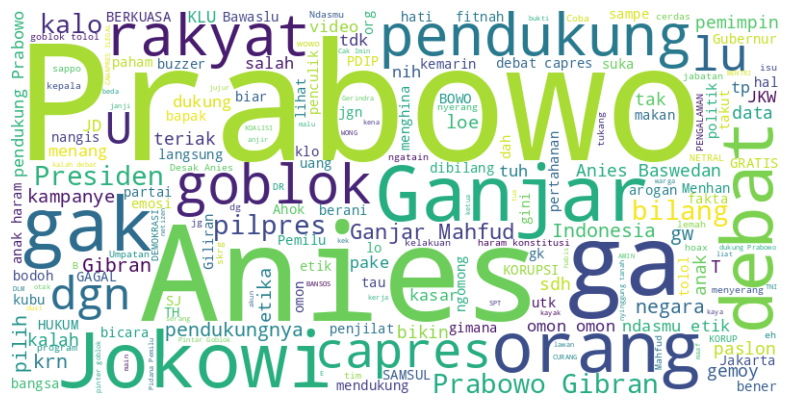

In [88]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nlp_id.stopword import StopWord
# Combine all the text into a single string
filtered_df = df[df['is_civil'] == '2']
text = ' '.join(filtered_df['content_cleaned'])

# text = "Lionel Messi pergi Ke pasar di area Jakarta Pusat" # single sentence
stopword = StopWord()
text = stopword.remove_stopword(text)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [83]:
filtered_df.head()

     index            created_at  \
73   41479  2024-01-04T00:43:49Z   
75   42131  2024-01-04T00:48:44Z   
80   43662  2024-01-04T01:00:41Z   
116  60656  2024-01-01T08:49:49Z   
154  74026  2024-01-02T15:50:52Z   

                                          username    tcode  num_retweets  \
73   @pWJ38uWoOoYTlRlk3FUez2YqBE+hzB563oPRZOg1Qno=    reply            14   
75   @d0It/CeEezLSlTrg5lEalwoLrTiczi+no11ZU+PT0N8=  mention           134   
80   @6B2iK9hjBOb3W1RmV7sr/EGS0PQbLbPLi49t23t0AN4=    reply            38   
116  @BAem1nwK5gk5f1a6LO5/ctBrwskcaeCZM1YnQYvxFME=  mention            25   
154  @55DNujBs53CmBQET/bjJaA1v7jtV6Di1XqNi0NP1zGg=  mention            14   

     type  frn_cnt  flw_cnt  sts_cnt                    loc  lst_cnt  \
73   twit      996    13370    84935        In her dream...        8   
75   twit      996    13370    84935        In her dream...        8   
80   twit      402      291    25972  di sebelah tetangga..        2   
116  twit    22225    36342   11

In [ ]:
df_label.head()

   Unnamed: 0  index            created_at  \
0           0    526  2024-01-04T10:00:02Z   
1           1    998  2024-01-04T10:03:01Z   
2           2   1128  2024-01-04T10:03:52Z   
3           3   1526  2024-01-04T10:06:00Z   
4           4   1627  2024-01-04T10:06:35Z   

                                        username    tcode  num_retweets  type  \
0  @pPjzd62RgMh1avEi5na07MKDlnRM5ZNm+V+vjZX5Wi8=  mention            12  twit   
1  @NRGR4Rg2rRAgA6kEvGs2jZR8JyFat6xFsR7eFMG/n1E=  mention            69  twit   
2  @IKU42+Xmr21zBvHXNHIVLfP73SXvISIS/iW6V0mABb8=  mention           102  twit   
3  @0lq6sgYkz8h5X2tdckKbMjbtJQ6NqzTtUIZcbXmzoUs=  mention           154  twit   
4  @1QTS7DAyncUQafq+ohwhfsOf78cYDP2qISmpQjfnoSQ=  mention            69  twit   

   frn_cnt  flw_cnt  sts_cnt  ... lang  \
0     8437    94847   384997  ...   id   
1       29  2216010  1272587  ...   id   
2    12034    17782    63910  ...   id   
3       31      405      690  ...   id   
4       50  9846987   4189

In [ ]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17182 entries, 0 to 17181
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       17182 non-null  int64  
 1   id               17182 non-null  int64  
 2   label            17182 non-null  object 
 3   Timestamp        0 non-null      float64
 4   timestamp        0 non-null      float64
 5   num_retweets     17182 non-null  int64  
 6   content_cleaned  17182 non-null  object 
 7   group            17182 non-null  int64  
 8   anies_stance     17182 non-null  object 
 9   prabowo_stance   17182 non-null  object 
 10  ganjar_stance    17182 non-null  object 
 11  title            17182 non-null  object 
 12  class            17182 non-null  int64  
 13  count            17182 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.8+ MB


In [ ]:
df_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17182 entries, 0 to 17181
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Unnamed: 0                  17182 non-null  int64 
 1   index                       17182 non-null  int64 
 2   created_at                  17182 non-null  object
 3   username                    17123 non-null  object
 4   tcode                       17182 non-null  object
 5   num_retweets                17182 non-null  int64 
 6   type                        17182 non-null  object
 7   frn_cnt                     17182 non-null  int64 
 8   flw_cnt                     17182 non-null  int64 
 9   sts_cnt                     17182 non-null  int64 
 10  loc                         11209 non-null  object
 11  lst_cnt                     17182 non-null  int64 
 12  content                     17182 non-null  object
 13  lang                        17182 non-null  ob

In [ ]:
df_cluster.head()

   Unnamed: 0  id                                              label  \
0           0   0  Mahfud MD bercerita tentang persahabatannya de...   
1           1   1  Calon presiden Anies Baswedan menyindir ucapan...   
2           2   2  AM1NKeun CIAMIS Pak Anies Rasyid Baswedan seny...   
3           3   3  Prabowo Gibran punya strategi konkret untuk me...   
4           4   4  Program Susu Gratis Tuai Kecaman Prabowo Beber...   

   Timestamp  timestamp  num_retweets  \
0        NaN        NaN            12   
1        NaN        NaN            69   
2        NaN        NaN           102   
3        NaN        NaN           154   
4        NaN        NaN            69   

                                     content_cleaned  group anies_stance  \
0  Mahfud MD bercerita tentang persahabatannya de...      0      Neutral   
1  Calon presiden Anies Baswedan menyindir ucapan...      1          Pro   
2  AM1NKeun CIAMIS Pak Anies Rasyid Baswedan seny...      2          Pro   
3  Prabowo Gibra

In [ ]:
df_sorted = df.sort_values(by='created_at')

# Reset index if needed
df_sorted = df_sorted.reset_index(drop=True)

In [ ]:
df_sorted.tail()

         index            created_at  \
17177  7325009  2024-01-31T17:01:45Z   
17178  7325164  2024-01-31T17:03:49Z   
17179  7327784  2024-01-31T17:29:32Z   
17180  7327907  2024-01-31T17:31:03Z   
17181  7328765  2024-01-31T17:40:49Z   

                                            username    tcode  num_retweets  \
17177  @cewlkPuAyPV9JrCXKADyQJBnezxEHH5FRF/eaLGJxyk=  mention            33   
17178  @ap7Fa0FeInD8xmDZPnmaN80bjP7KlgeiC9QSqW7cmgA=  mention            13   
17179  @LSsgd69UOR8Mlnj1qCrA83ARMeOldyvCTGtqcAd4Soc=  mention           344   
17180  @xv4EkBHQICjEoh1tRMu5X0dnjN3G8qXSJkfTYVOEnf0=  mention            11   
17181  @eCaJUPeZLggjtt1RYLv7BJgQOzquob1RWYHUspKtjII=  mention            12   

       type  frn_cnt  flw_cnt  sts_cnt                      loc  lst_cnt  \
17177  twit     3553    83608    31584                   Warteg       48   
17178  twit       11     1556      130                      NaN        1   
17179  twit      483    77010    16037  DKI Jakarta - In

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17182 entries, 0 to 17181
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   index                       17182 non-null  int64 
 1   created_at                  17182 non-null  object
 2   username                    17123 non-null  object
 3   tcode                       17182 non-null  object
 4   num_retweets                17182 non-null  int64 
 5   type                        17182 non-null  object
 6   frn_cnt                     17182 non-null  int64 
 7   flw_cnt                     17182 non-null  int64 
 8   sts_cnt                     17182 non-null  int64 
 9   loc                         11209 non-null  object
 10  lst_cnt                     17182 non-null  int64 
 11  content                     17182 non-null  object
 12  lang                        17182 non-null  object
 13  content_cleaned             17182 non-null  ob

# STANCE

## Load Data

In [25]:
df = pd.read_csv(f"{DATA_DIR}/df_with_pred.csv")

In [26]:
df_label.head(1)

NameError: name 'df_label' is not defined

In [ ]:
df_label['anies_pred'].value_counts()

anies_pred
0    10051
1     5548
2     1583
Name: count, dtype: int64

In [ ]:
df.head()

In [27]:
df['anies_pred'] = df['anies_pred'].astype(int)
df['ganjar_pred'] = df['ganjar_pred'].astype(int)
df['prabowo_pred'] = df['prabowo_pred'].astype(int)

In [28]:
df.head()

   Unnamed: 0  index            created_at  \
0           0    526  2024-01-04T10:00:02Z   
1           1    998  2024-01-04T10:03:01Z   
2           2   1128  2024-01-04T10:03:52Z   
3           3   1526  2024-01-04T10:06:00Z   
4           4   1627  2024-01-04T10:06:35Z   

                                        username    tcode  num_retweets  type  \
0  @pPjzd62RgMh1avEi5na07MKDlnRM5ZNm+V+vjZX5Wi8=  mention            12  twit   
1  @NRGR4Rg2rRAgA6kEvGs2jZR8JyFat6xFsR7eFMG/n1E=  mention            69  twit   
2  @IKU42+Xmr21zBvHXNHIVLfP73SXvISIS/iW6V0mABb8=  mention           102  twit   
3  @0lq6sgYkz8h5X2tdckKbMjbtJQ6NqzTtUIZcbXmzoUs=  mention           154  twit   
4  @1QTS7DAyncUQafq+ohwhfsOf78cYDP2qISmpQjfnoSQ=  mention            69  twit   

   frn_cnt  flw_cnt  sts_cnt  ... lang  \
0     8437    94847   384997  ...   id   
1       29  2216010  1272587  ...   id   
2    12034    17782    63910  ...   id   
3       31      405      690  ...   id   
4       50  9846987   4189

In [ ]:
df['anies_stance'].value_counts()

In [29]:
df['anies_pred'].value_counts()

anies_pred
0    10051
1     5548
2     1583
Name: count, dtype: int64

In [30]:
df['created_at'] = pd.to_datetime(df['created_at'])
# Group by day
# Define a custom aggregation function
def count_stances(series, value):
    return (series == value).sum()

# Group by day and count occurrences of each stance
grouped_df = df.groupby(pd.Grouper(key='created_at', freq='D')).agg(
    total_count=('anies_pred', 'size'),
    anies_1=('anies_pred', lambda x: count_stances(x, 1)),
    anies_0=('anies_pred', lambda x: count_stances(x, 0)),
    anies_minus_1=('anies_pred', lambda x: count_stances(x, 2)),
    prabowo_1=('prabowo_pred', lambda x: count_stances(x, 1)),
    prabowo_0=('prabowo_pred', lambda x: count_stances(x, 0)),
    prabowo_minus_1=('prabowo_pred', lambda x: count_stances(x, 2)),
    ganjar_1=('ganjar_pred', lambda x: count_stances(x, 1)),
    ganjar_0=('ganjar_pred', lambda x: count_stances(x, 0)),
    ganjar_minus_1=('ganjar_pred', lambda x: count_stances(x, 2))
).reset_index()

In [ ]:
grouped_df.head()

                 created_at  total_count  anies_1  anies_0  anies_minus_1  \
0 2023-12-31 00:00:00+00:00           76       35       36              0   
1 2024-01-01 00:00:00+00:00          707      271      385              0   
2 2024-01-02 00:00:00+00:00          427       92      309              0   
3 2024-01-03 00:00:00+00:00          577      197      343              0   
4 2024-01-04 00:00:00+00:00          569      208      313              0   

   prabowo_1  prabowo_0  prabowo_minus_1  ganjar_1  ganjar_0  ganjar_minus_1  
0         10         59                0        21        55               0  
1        118        471                0       227       448               0  
2        125        219                0       143       269               0  
3        119        367                0       184       375               0  
4        109        402                0       171       378               0  

In [ ]:
grouped_df.info()

## Visualize

### Option 1 (Stacked Chart)

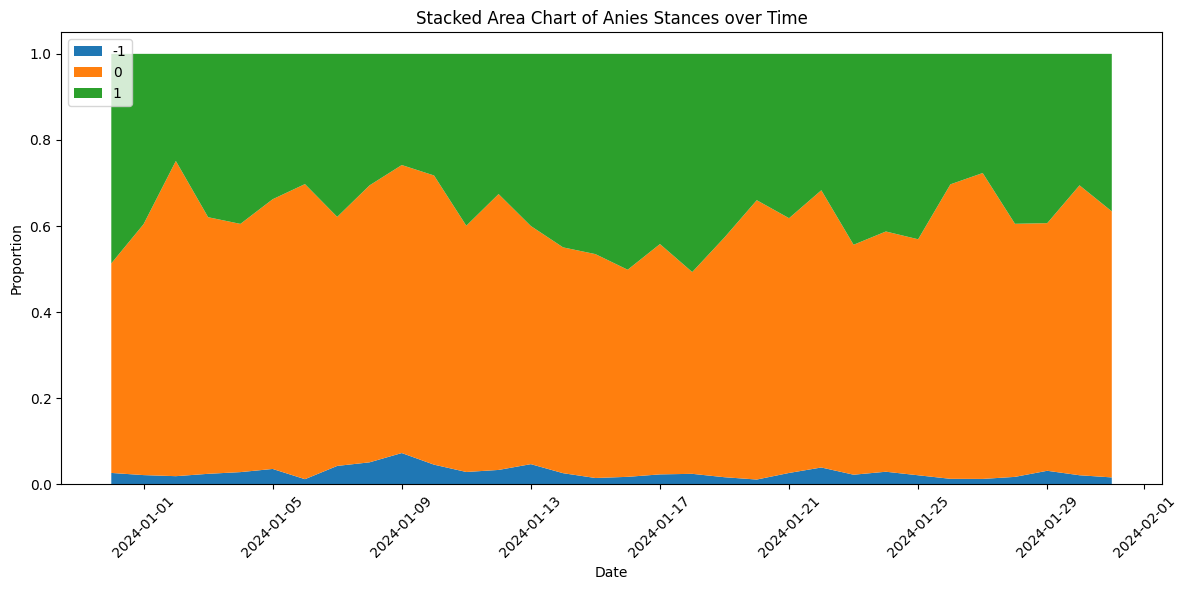

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate proportions
grouped_df['y1'] = grouped_df['anies_minus_1'] / grouped_df['total_count']
grouped_df['y2'] = grouped_df['anies_0'] / grouped_df['total_count']
grouped_df['y3'] = grouped_df['anies_1'] / grouped_df['total_count']

# Plotting
plt.figure(figsize=(12, 6))
plt.stackplot(grouped_df['created_at'], grouped_df['y1'], grouped_df['y2'], grouped_df['y3'], labels=['-1', '0', '1'])
plt.legend(loc='upper left')
plt.title('Stacked Area Chart of Anies Stances over Time')
plt.xlabel('Date')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

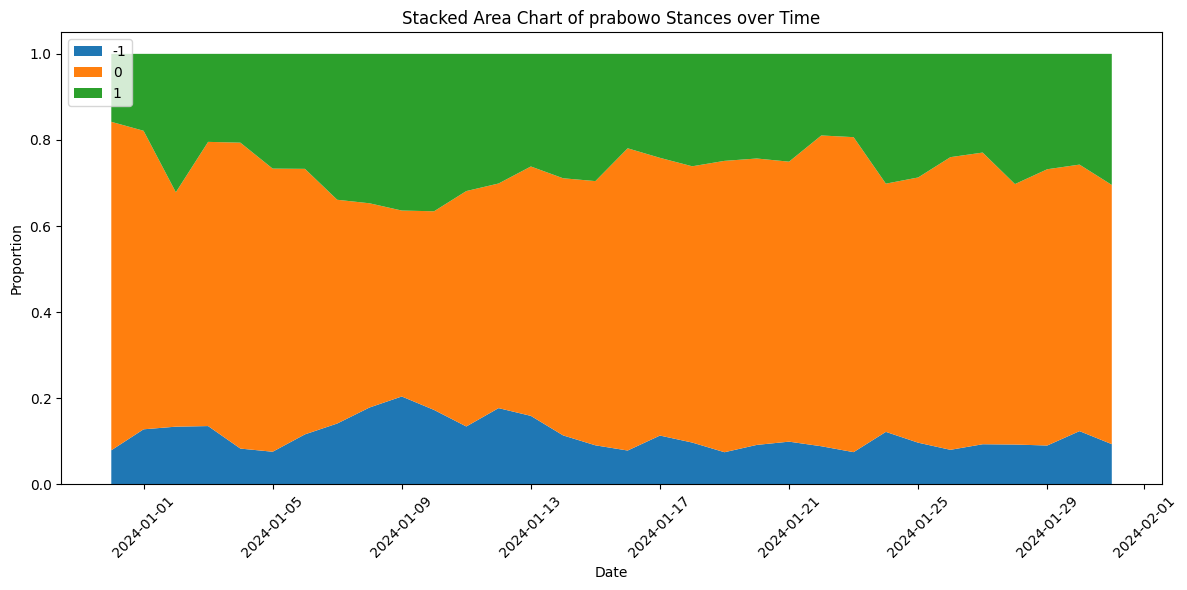

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate proportions
grouped_df['y1'] = grouped_df['prabowo_minus_1'] / grouped_df['total_count']
grouped_df['y2'] = grouped_df['prabowo_0'] / grouped_df['total_count']
grouped_df['y3'] = grouped_df['prabowo_1'] / grouped_df['total_count']

# Plotting
plt.figure(figsize=(12, 6))
plt.stackplot(grouped_df['created_at'], grouped_df['y1'], grouped_df['y2'], grouped_df['y3'], labels=['-1', '0', '1'])
plt.legend(loc='upper left')
plt.title('Stacked Area Chart of prabowo Stances over Time')
plt.xlabel('Date')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

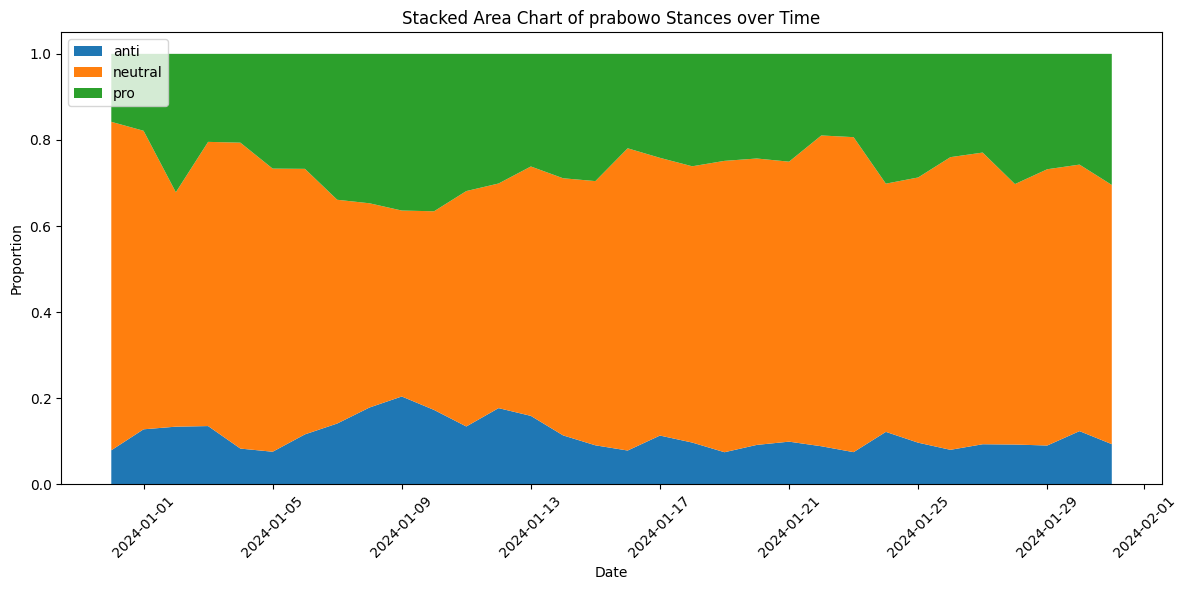

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate proportions
grouped_df['y1'] = grouped_df['prabowo_minus_1'] / grouped_df['total_count']
grouped_df['y2'] = grouped_df['prabowo_0'] / grouped_df['total_count']
grouped_df['y3'] = grouped_df['prabowo_1'] / grouped_df['total_count']

# Plotting
plt.figure(figsize=(12, 6))
plt.stackplot(grouped_df['created_at'], grouped_df['y1'], grouped_df['y2'], grouped_df['y3'], labels=['anti', 'neutral', 'pro'])
plt.legend(loc='upper left')
plt.title('Stacked Area Chart of prabowo Stances over Time')
plt.xlabel('Date')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

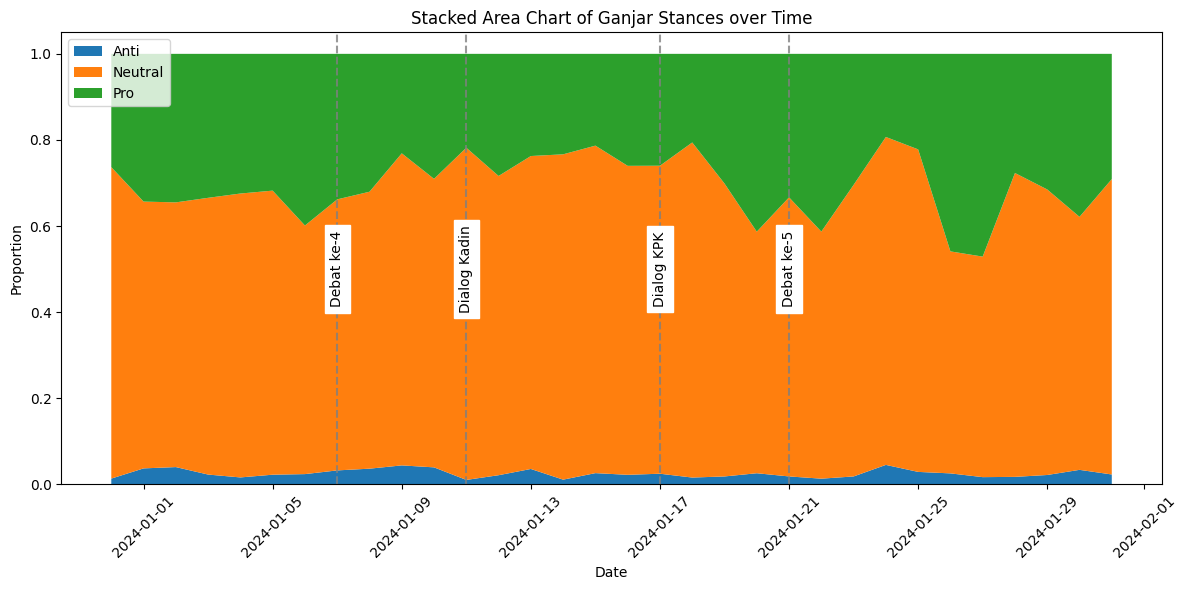

In [ ]:
# Calculate proportions
grouped_df['y1'] = grouped_df['ganjar_minus_1'] / grouped_df['total_count']
grouped_df['y2'] = grouped_df['ganjar_0'] / grouped_df['total_count']
grouped_df['y3'] = grouped_df['ganjar_1'] / grouped_df['total_count']

# Plotting stacked area chart
plt.figure(figsize=(12, 6))
plt.stackplot(grouped_df['created_at'], grouped_df['y1'], grouped_df['y2'], grouped_df['y3'], labels=['Anti', 'Neutral', 'Pro'])

# Marking and labeling important dates
important_dates = [('2024-01-07', 'Debat ke-4'),
                   ('2024-01-11', 'Dialog Kadin'),
                   ('2024-01-17', 'Dialog KPK'),
                   ('2024-01-21', 'Debat ke-5')]

for date, label in important_dates:
    plt.axvline(pd.to_datetime(date), color='gray', linestyle='--', alpha=0.8)  # Add a vertical line for each date
    plt.text(pd.to_datetime(date), 0.5, label, rotation=90, va='center', ha='center', backgroundcolor='white')

# Customizing plot
plt.legend(loc='upper left')
plt.title('Stacked Area Chart of Ganjar Stances over Time')
plt.xlabel('Date')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

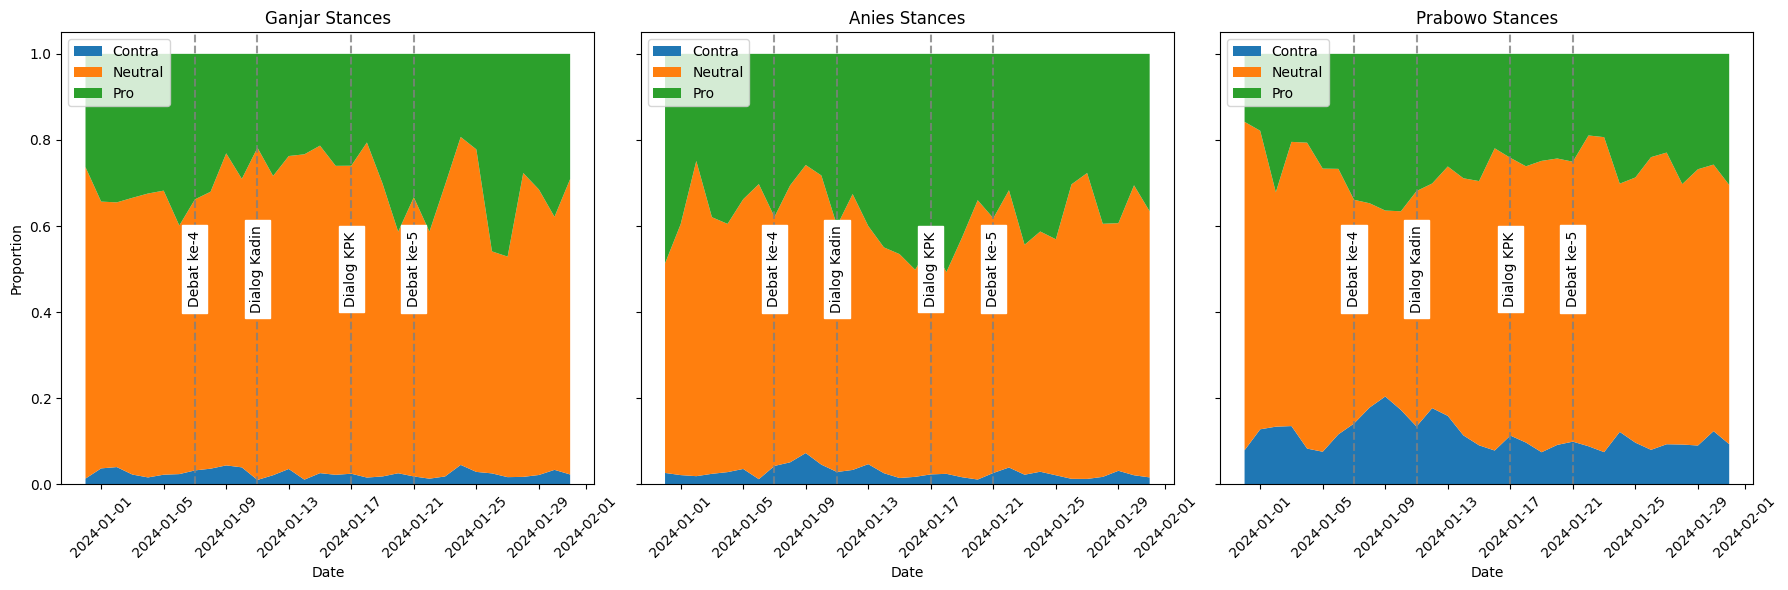

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'grouped_df' and 'important_dates' are already defined

# Calculate proportions for Ganjar
grouped_df['y1_ganjar'] = grouped_df['ganjar_minus_1'] / grouped_df['total_count']
grouped_df['y2_ganjar'] = grouped_df['ganjar_0'] / grouped_df['total_count']
grouped_df['y3_ganjar'] = grouped_df['ganjar_1'] / grouped_df['total_count']

# Calculate proportions for Anies
grouped_df['y1_anies'] = grouped_df['anies_minus_1'] / grouped_df['total_count']
grouped_df['y2_anies'] = grouped_df['anies_0'] / grouped_df['total_count']
grouped_df['y3_anies'] = grouped_df['anies_1'] / grouped_df['total_count']

# Calculate proportions for Prabowo
grouped_df['y1_prabowo'] = grouped_df['prabowo_minus_1'] / grouped_df['total_count']
grouped_df['y2_prabowo'] = grouped_df['prabowo_0'] / grouped_df['total_count']
grouped_df['y3_prabowo'] = grouped_df['prabowo_1'] / grouped_df['total_count']

# Create subplots with shared y-axis
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)

# Plotting stacked area chart for Ganjar
ax1.stackplot(grouped_df['created_at'], grouped_df['y1_ganjar'], grouped_df['y2_ganjar'], grouped_df['y3_ganjar'], labels=['Contra', 'Neutral', 'Pro'])
ax1.set_title('Ganjar Stances')
ax1.set_xlabel('Date')
ax1.set_ylabel('Proportion')
ax1.legend(loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# Plotting stacked area chart for Anies
ax2.stackplot(grouped_df['created_at'], grouped_df['y1_anies'], grouped_df['y2_anies'], grouped_df['y3_anies'], labels=['Contra', 'Neutral', 'Pro'])
ax2.set_title('Anies Stances')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.tick_params(axis='x', rotation=45)

# Plotting stacked area chart for Prabowo
ax3.stackplot(grouped_df['created_at'], grouped_df['y1_prabowo'], grouped_df['y2_prabowo'], grouped_df['y3_prabowo'], labels=['Contra', 'Neutral', 'Pro'])
ax3.set_title('Prabowo Stances')
ax3.set_xlabel('Date')
ax3.legend(loc='upper left')
ax3.tick_params(axis='x', rotation=45)

# Adding vertical lines and labels for important dates
for ax in [ax1, ax2, ax3]:
    for date, label in important_dates:
        ax.axvline(pd.to_datetime(date), color='gray', linestyle='--', alpha=0.8)
        ax.text(pd.to_datetime(date), 0.5, label, rotation=90, va='center', ha='center', backgroundcolor='white')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

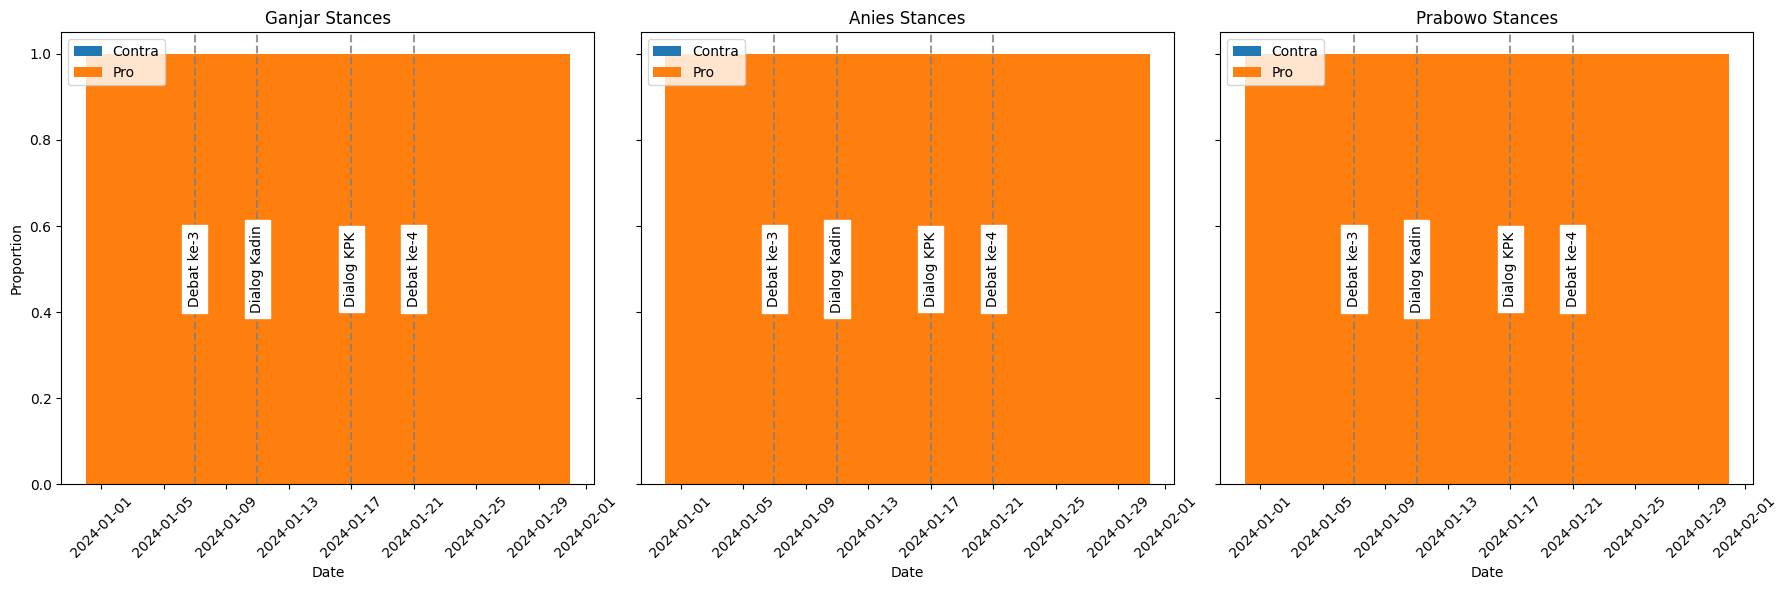

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'grouped_df' and 'important_dates' are already defined

# Calculate proportions for Ganjar
grouped_df['y1_ganjar'] = grouped_df['ganjar_minus_1'] / (grouped_df['ganjar_minus_1'] + grouped_df['ganjar_1'])
# grouped_df['y2_ganjar'] = grouped_df['ganjar_0'] / grouped_df['total_count']
grouped_df['y3_ganjar'] = grouped_df['ganjar_1'] / (grouped_df['ganjar_minus_1'] + grouped_df['ganjar_1'])

# Calculate proportions for Ganjar
grouped_df['y1_anies'] = grouped_df['anies_minus_1'] / (grouped_df['anies_minus_1'] + grouped_df['anies_1'])
# grouped_df['y2_anies'] = grouped_df['anies_0'] / grouped_df['total_count']
grouped_df['y3_anies'] = grouped_df['anies_1'] / (grouped_df['anies_minus_1'] + grouped_df['anies_1'])

# Calculate proportions for Ganjar
grouped_df['y1_prabowo'] = grouped_df['prabowo_minus_1'] / (grouped_df['prabowo_minus_1'] + grouped_df['prabowo_1'])
# grouped_df['y2_prabowo'] = grouped_df['prabowo_0'] / grouped_df['total_count']
grouped_df['y3_prabowo'] = grouped_df['prabowo_1'] / (grouped_df['prabowo_minus_1'] + grouped_df['prabowo_1'])

# Create subplots with shared y-axis
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)

# Plotting stacked area chart for Ganjar
ax1.stackplot(grouped_df['created_at'], grouped_df['y1_ganjar'], grouped_df['y3_ganjar'], labels=['Contra', 'Pro'])
ax1.set_title('Ganjar Stances')
ax1.set_xlabel('Date')
ax1.set_ylabel('Proportion')
ax1.legend(loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# Plotting stacked area chart for Anies
ax2.stackplot(grouped_df['created_at'], grouped_df['y1_anies'], grouped_df['y3_anies'], labels=['Contra', 'Pro'])
ax2.set_title('Anies Stances')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.tick_params(axis='x', rotation=45)

# Plotting stacked area chart for Prabowo
ax3.stackplot(grouped_df['created_at'], grouped_df['y1_prabowo'], grouped_df['y3_prabowo'], labels=['Contra', 'Pro'])
ax3.set_title('Prabowo Stances')
ax3.set_xlabel('Date')
ax3.legend(loc='upper left')
ax3.tick_params(axis='x', rotation=45)

# Adding vertical lines and labels for important dates
for ax in [ax1, ax2, ax3]:
    for date, label in important_dates:
        ax.axvline(pd.to_datetime(date), color='gray', linestyle='--', alpha=0.8)
        ax.text(pd.to_datetime(date), 0.5, label, rotation=90, va='center', ha='center', backgroundcolor='white')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [ ]:
important_dates = [('2024-01-07', 'Debat ke-4'),
                   ('2024-01-11', 'Dialog Kadin'),
                   ('2024-01-17', 'Dialog KPK'),
                   ('2024-01-21', 'Debat ke-5')]

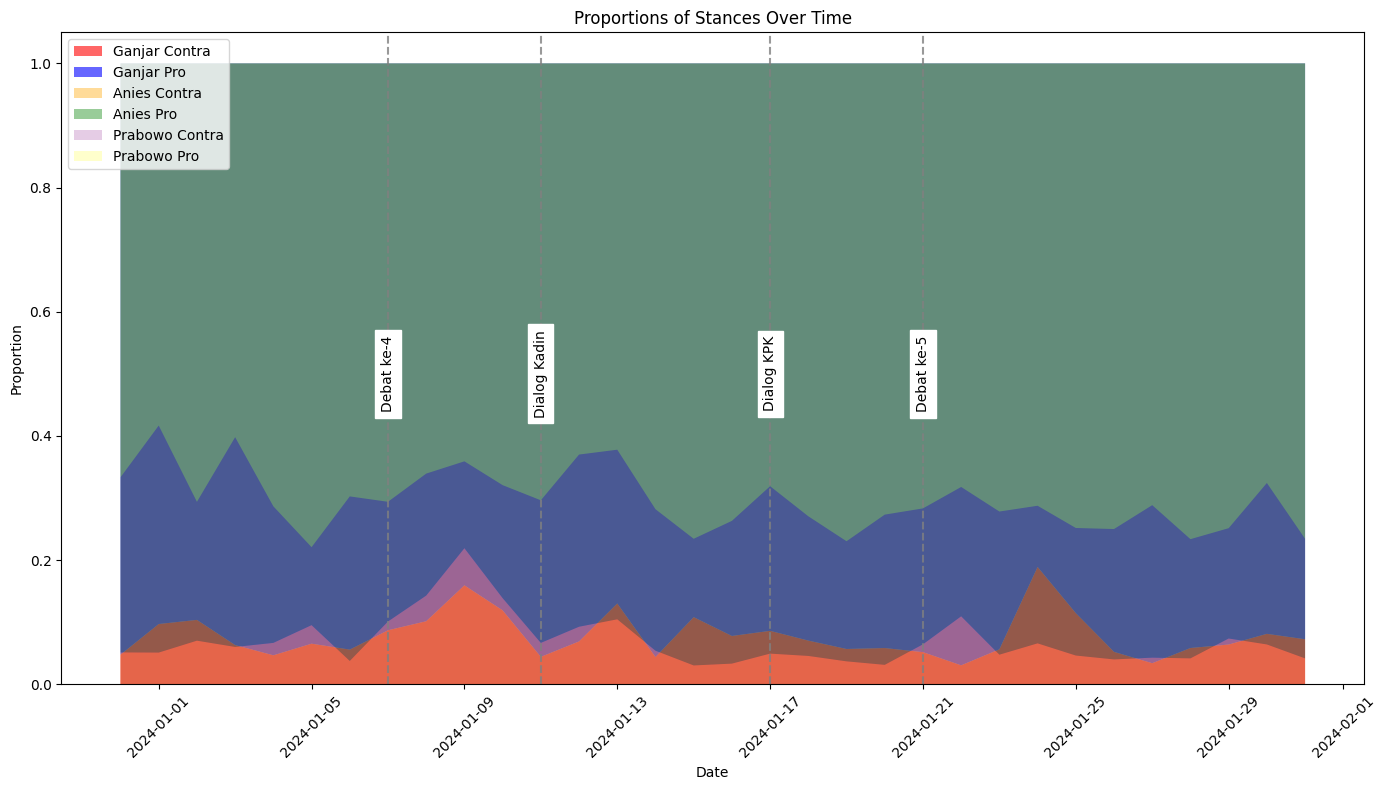

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'grouped_df' and 'important_dates' are already defined

# Calculate proportions for Ganjar
grouped_df['y1_ganjar'] = grouped_df['ganjar_minus_1'] / (grouped_df['ganjar_minus_1'] + grouped_df['ganjar_1'])
grouped_df['y3_ganjar'] = grouped_df['ganjar_1'] / (grouped_df['ganjar_minus_1'] + grouped_df['ganjar_1'])

# Calculate proportions for Anies
grouped_df['y1_anies'] = grouped_df['anies_minus_1'] / (grouped_df['anies_minus_1'] + grouped_df['anies_1'])
grouped_df['y3_anies'] = grouped_df['anies_1'] / (grouped_df['anies_minus_1'] + grouped_df['anies_1'])

# Calculate proportions for Prabowo
grouped_df['y1_prabowo'] = grouped_df['prabowo_minus_1'] / (grouped_df['prabowo_minus_1'] + grouped_df['prabowo_1'])
grouped_df['y3_prabowo'] = grouped_df['prabowo_1'] / (grouped_df['prabowo_minus_1'] + grouped_df['prabowo_1'])

# Create a plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plotting stacked area chart for Ganjar
ax.stackplot(grouped_df['created_at'], grouped_df['y1_ganjar'], grouped_df['y3_ganjar'], labels=['Ganjar Contra', 'Ganjar Pro'], colors=['red', 'blue'], alpha=0.6)

# Plotting stacked area chart for Anies
ax.stackplot(grouped_df['created_at'], grouped_df['y1_anies'], grouped_df['y3_anies'], labels=['Anies Contra', 'Anies Pro'], colors=['orange', 'green'], alpha=0.4)

# Plotting stacked area chart for Prabowo
ax.stackplot(grouped_df['created_at'], grouped_df['y1_prabowo'], grouped_df['y3_prabowo'], labels=['Prabowo Contra', 'Prabowo Pro'], colors=['purple', 'yellow'], alpha=0.2)

# Set plot title and labels
ax.set_title('Proportions of Stances Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Proportion')

# Add legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left')

# Rotate x-axis labels
ax.tick_params(axis='x', rotation=45)

# Adding vertical lines and labels for important dates
for date, label in important_dates:
    ax.axvline(pd.to_datetime(date), color='gray', linestyle='--', alpha=0.8)
    ax.text(pd.to_datetime(date), 0.5, label, rotation=90, va='center', ha='center', backgroundcolor='white')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

### Option 2

### Final Chart

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'grouped_df' and 'important_dates' are already defined

# Calculate proportions for Ganjar
grouped_df['y1_ganjar'] = grouped_df['ganjar_minus_1'] / (grouped_df['ganjar_minus_1'] + grouped_df['ganjar_1'])
# grouped_df['y2_ganjar'] = grouped_df['ganjar_0'] / grouped_df['total_count']
grouped_df['y3_ganjar'] = grouped_df['ganjar_1'] / (grouped_df['ganjar_minus_1'] + grouped_df['ganjar_1'])

# Calculate proportions for Ganjar
grouped_df['y1_anies'] = grouped_df['anies_minus_1'] / (grouped_df['anies_minus_1'] + grouped_df['anies_1'])
# grouped_df['y2_anies'] = grouped_df['anies_0'] / grouped_df['total_count']
grouped_df['y3_anies'] = grouped_df['anies_1'] / (grouped_df['anies_minus_1'] + grouped_df['anies_1'])

# Calculate proportions for Ganjar
grouped_df['y1_prabowo'] = grouped_df['prabowo_minus_1'] / (grouped_df['prabowo_minus_1'] + grouped_df['prabowo_1'])
# grouped_df['y2_prabowo'] = grouped_df['prabowo_0'] / grouped_df['total_count']
grouped_df['y3_prabowo'] = grouped_df['prabowo_1'] / (grouped_df['prabowo_minus_1'] + grouped_df['prabowo_1'])

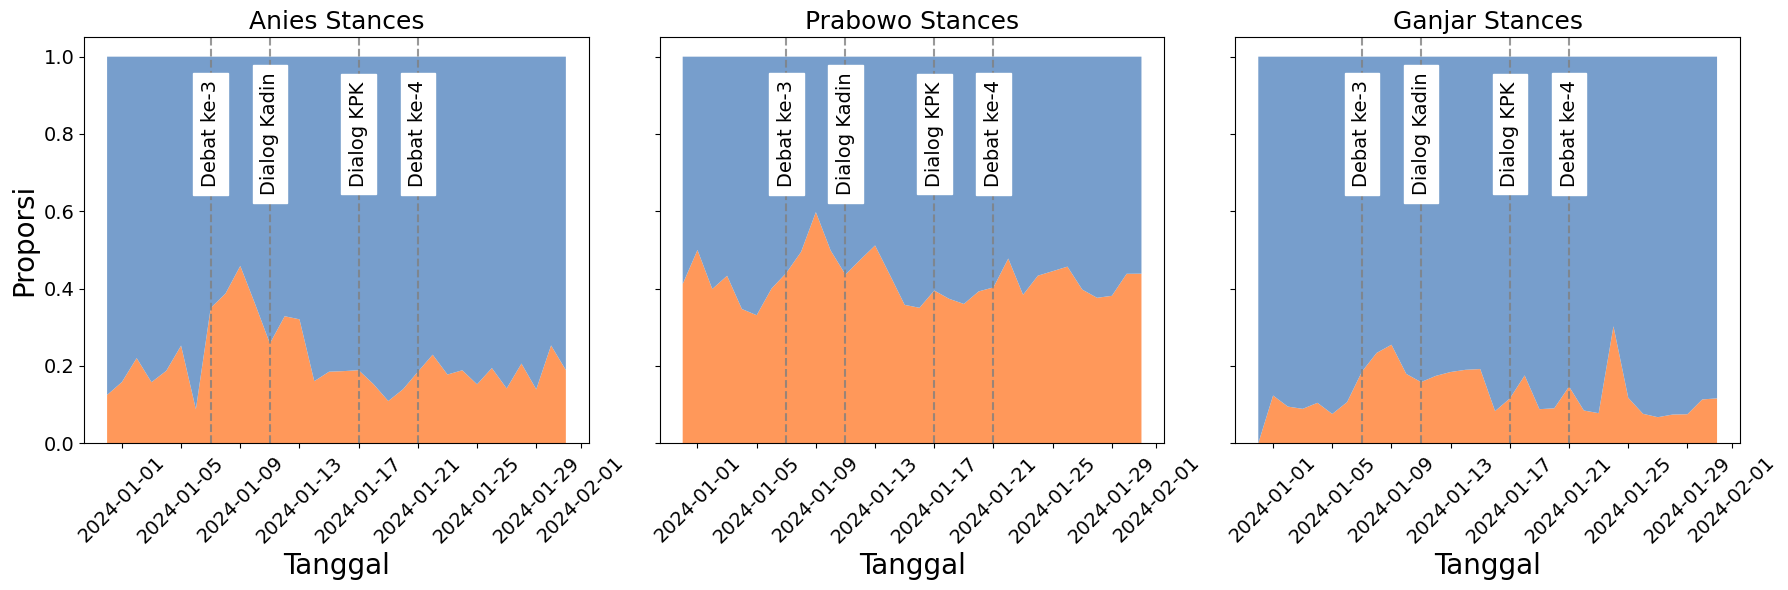

In [44]:
import matplotlib.pyplot as plt

# Define pastel colors
pastel_orange = '#FF985A'
pastel_blue = '#779ECC'

# Create subplots with shared y-axis
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)

# Font size for various elements
title_fontsize = 18
label_fontsize = 20
tick_fontsize = 14
legend_fontsize = 14


# Plotting stacked area chart for Anies
ax1.stackplot(grouped_df['created_at'], grouped_df['y1_anies'], grouped_df['y3_anies'],
              labels=['Kontra', 'Pro'], colors=[pastel_orange, pastel_blue])
ax1.set_title('Anies Stances', fontsize=title_fontsize)
ax1.set_xlabel('Tanggal', fontsize=label_fontsize)
ax1.set_ylabel('Proporsi', fontsize=label_fontsize)
# ax1.legend(loc='upper right', fontsize=legend_fontsize)
ax1.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
ax1.tick_params(axis='y', labelsize=tick_fontsize)

# Plotting stacked area chart for Prabowo
ax2.stackplot(grouped_df['created_at'], grouped_df['y1_prabowo'], grouped_df['y3_prabowo'],
              labels=['Kontra', 'Pro'], colors=[pastel_orange, pastel_blue])
ax2.set_title('Prabowo Stances', fontsize=title_fontsize)
ax2.set_xlabel('Tanggal', fontsize=label_fontsize)
# ax2.legend(loc='upper right', fontsize=legend_fontsize)
ax2.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
ax2.tick_params(axis='y', labelsize=tick_fontsize)

# Plotting stacked area chart for Ganjar
ax3.stackplot(grouped_df['created_at'], grouped_df['y1_ganjar'], grouped_df['y3_ganjar'],
              labels=['Kontra', 'Pro'], colors=[pastel_orange, pastel_blue])
ax3.set_title('Ganjar Stances', fontsize=title_fontsize)
ax3.set_xlabel('Tanggal', fontsize=label_fontsize)
# ax3.legend(loc='upper right', fontsize=legend_fontsize)
ax3.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
ax3.tick_params(axis='y', labelsize=tick_fontsize)

# Adding vertical lines and labels for important dates
for ax in [ax1, ax2, ax3]:
    for date, label in important_dates:
        ax.axvline(pd.to_datetime(date), color='gray', linestyle='--', alpha=0.8)
        ax.text(pd.to_datetime(date), 0.8, label, rotation=90, va='center', ha='center', backgroundcolor='white', fontsize=tick_fontsize)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [42]:
grouped_df.head()

                 created_at  total_count  anies_1  anies_0  anies_minus_1  \
0 2023-12-31 00:00:00+00:00           76       35       36              5   
1 2024-01-01 00:00:00+00:00          707      271      385             51   
2 2024-01-02 00:00:00+00:00          427       92      309             26   
3 2024-01-03 00:00:00+00:00          577      197      343             37   
4 2024-01-04 00:00:00+00:00          569      208      313             48   

   prabowo_1  prabowo_0  prabowo_minus_1  ganjar_1  ganjar_0  ganjar_minus_1  \
0         10         59                7        21        55               0   
1        118        471              118       227       448              32   
2        125        219               83       143       269              15   
3        119        367               91       184       375              18   
4        109        402               58       171       378              20   

   y1_ganjar  y3_ganjar  y1_anies  y3_anies  y1_prabowo 

<ipython-input-41-b8b22d1c07be>:25: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['day'] = df['created_at'].dt.to_period('D')
<ipython-input-41-b8b22d1c07be>:25: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['day'] = df['created_at'].dt.to_period('D')
<ipython-input-41-b8b22d1c07be>:25: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['day'] = df['created_at'].dt.to_period('D')


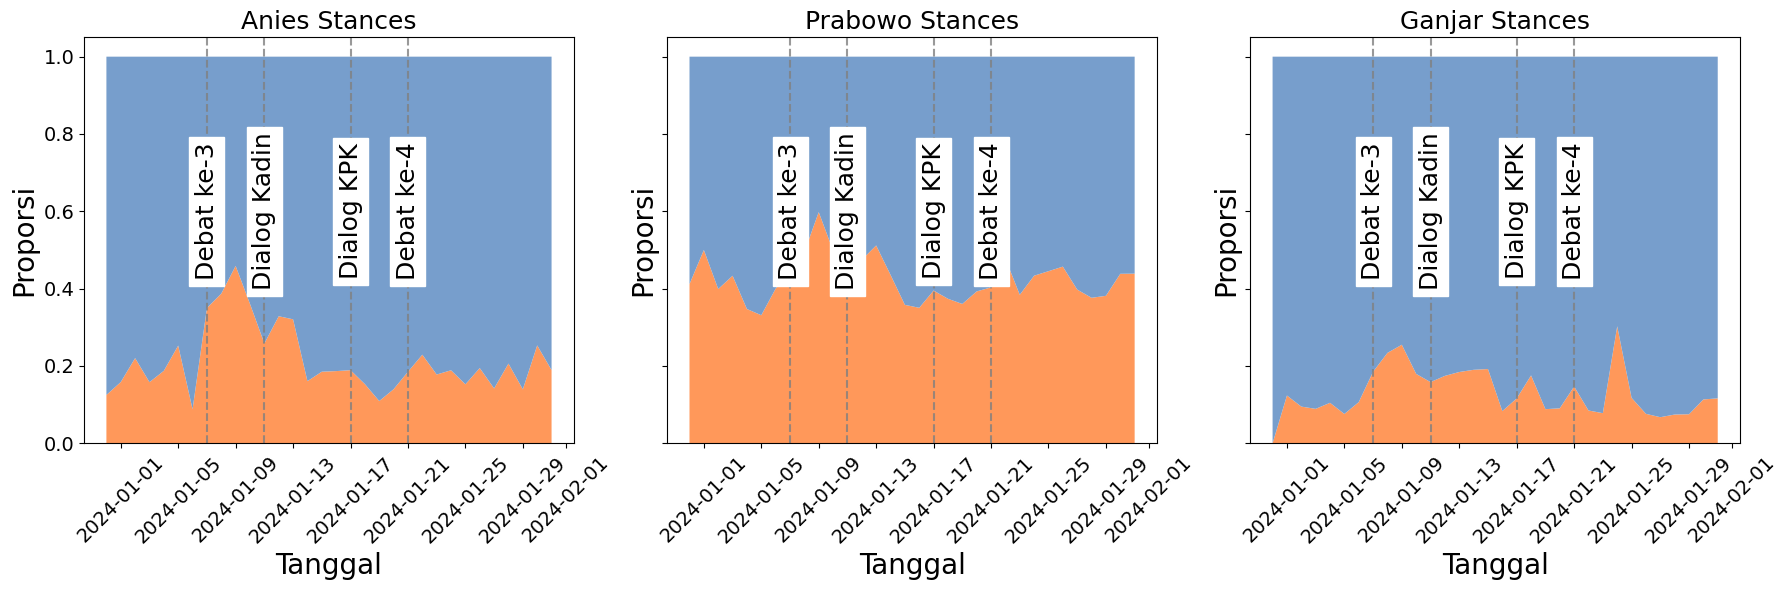

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming grouped_df, df_anies_cluster, df_prabowo_cluster, and df_ganjar_cluster are your DataFrames

# Convert 'created_at' to datetime if it is not already
grouped_df['created_at'] = pd.to_datetime(grouped_df['created_at'])

# Define pastel colors
pastel_orange = '#FF985A'
pastel_blue = '#779ECC'

# Create subplots with shared y-axis
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)

# Font size for various elements
title_fontsize = 18
label_fontsize = 20
tick_fontsize = 14
legend_fontsize = 14

# Function to plot stacked area chart with important dates
def plot_stacked_area_with_dates(ax, df, y1_col, y3_col, title, important_dates):
    # Group by day
    df['day'] = df['created_at'].dt.to_period('D')
    grouped = df.groupby('day')[[y1_col, y3_col]].sum()

    # Calculate proportions
    proportions = grouped.div(grouped.sum(axis=1), axis=0)

    # Plot stacked area chart
    ax.stackplot(proportions.index.to_timestamp(), proportions[y1_col], proportions[y3_col],
                 labels=['Kontra', 'Pro'], colors=[pastel_orange, pastel_blue])

    # Add important dates
    for date, label in important_dates:
        ax.axvline(pd.to_datetime(date), color='gray', linestyle='--', alpha=0.8)  # Add a vertical line for each date
        ax.text(pd.to_datetime(date), 0.6, label, rotation=90, va='center', ha='center', fontsize=18, backgroundcolor='white')

    # Customize the plot
    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xlabel('Tanggal', fontsize=label_fontsize)
    ax.set_ylabel('Proporsi', fontsize=label_fontsize)
    ax.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)

# Important dates
important_dates = [('2024-01-07', 'Debat ke-3'),
                   ('2024-01-11', 'Dialog Kadin'),
                   ('2024-01-17', 'Dialog KPK'),
                   ('2024-01-21', 'Debat ke-4')]

# Plot for Anies
plot_stacked_area_with_dates(ax1, grouped_df, 'y1_anies', 'y3_anies', 'Anies Stances', important_dates)

# Plot for Prabowo
plot_stacked_area_with_dates(ax2, grouped_df, 'y1_prabowo', 'y3_prabowo', 'Prabowo Stances', important_dates)

# Plot for Ganjar
plot_stacked_area_with_dates(ax3, grouped_df, 'y1_ganjar', 'y3_ganjar', 'Ganjar Stances', important_dates)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

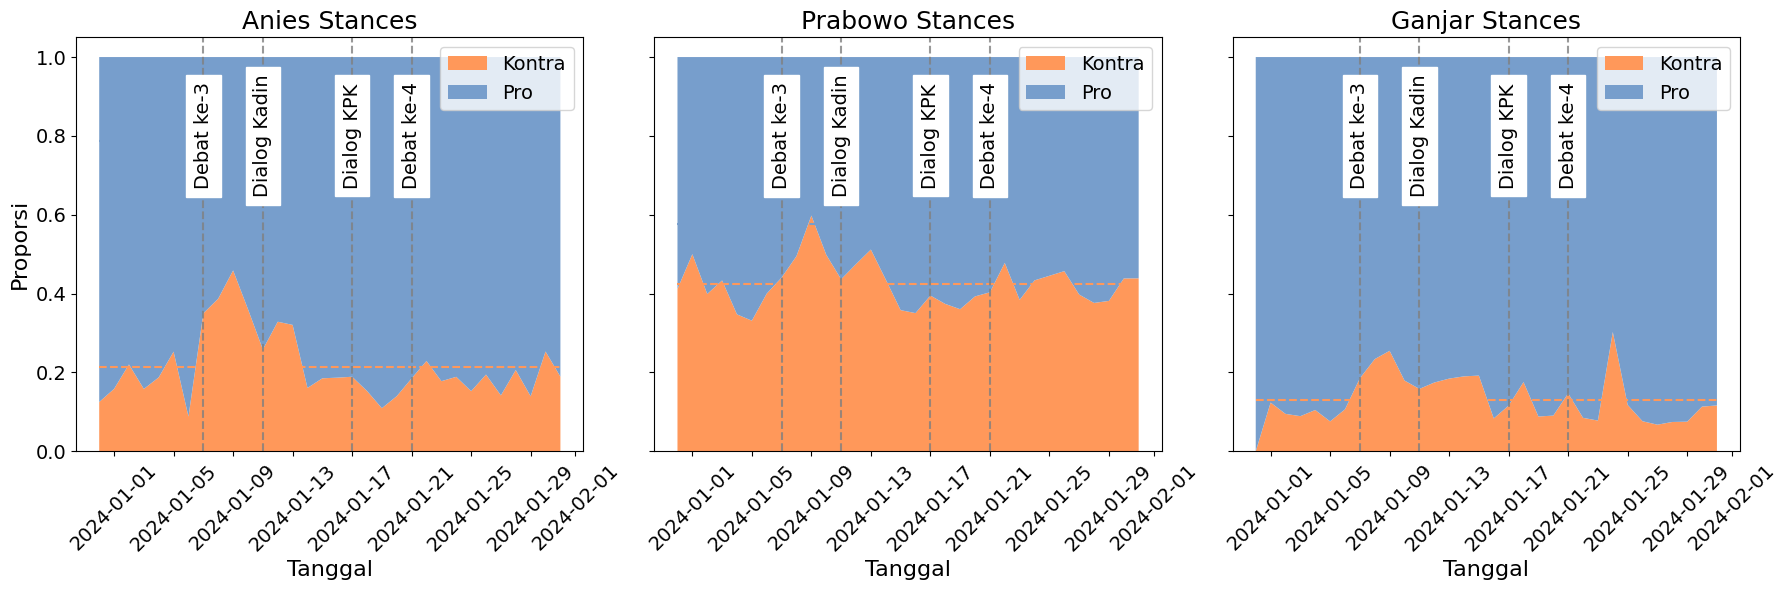

In [ ]:
import matplotlib.pyplot as plt

# Define pastel colors
pastel_orange = '#FF985A'
pastel_blue = '#779ECC'

# Calculate the average values for each stance
average_anies_kontra = grouped_df['y1_anies'].mean()
average_anies_pro = grouped_df['y3_anies'].mean()
average_prabowo_kontra = grouped_df['y1_prabowo'].mean()
average_prabowo_pro = grouped_df['y3_prabowo'].mean()
average_ganjar_kontra = grouped_df['y1_ganjar'].mean()
average_ganjar_pro = grouped_df['y3_ganjar'].mean()

# Create subplots with shared y-axis
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)

# Font size for various elements
title_fontsize = 18
label_fontsize = 16
tick_fontsize = 14
legend_fontsize = 14

# Plotting stacked area chart for Anies
ax1.stackplot(grouped_df['created_at'], grouped_df['y1_anies'], grouped_df['y3_anies'],
              labels=['Kontra', 'Pro'], colors=[pastel_orange, pastel_blue])
ax1.set_title('Anies Stances', fontsize=title_fontsize)
ax1.set_xlabel('Tanggal', fontsize=label_fontsize)
ax1.set_ylabel('Proporsi', fontsize=label_fontsize)
ax1.legend(loc='upper right', fontsize=legend_fontsize)
ax1.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
ax1.tick_params(axis='y', labelsize=tick_fontsize)
ax1.hlines(average_anies_kontra, xmin=grouped_df['created_at'].min(), xmax=grouped_df['created_at'].max(), colors=pastel_orange, linestyles='dashed', label='Avg Kontra')
ax1.hlines(average_anies_pro, xmin=grouped_df['created_at'].min(), xmax=grouped_df['created_at'].max(), colors=pastel_blue, linestyles='dashed', label='Avg Pro')

# Plotting stacked area chart for Prabowo
ax2.stackplot(grouped_df['created_at'], grouped_df['y1_prabowo'], grouped_df['y3_prabowo'],
              labels=['Kontra', 'Pro'], colors=[pastel_orange, pastel_blue])
ax2.set_title('Prabowo Stances', fontsize=title_fontsize)
ax2.set_xlabel('Tanggal', fontsize=label_fontsize)
ax2.legend(loc='upper right', fontsize=legend_fontsize)
ax2.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
ax2.tick_params(axis='y', labelsize=tick_fontsize)
ax2.hlines(average_prabowo_kontra, xmin=grouped_df['created_at'].min(), xmax=grouped_df['created_at'].max(), colors=pastel_orange, linestyles='dashed', label='Avg Kontra')
ax2.hlines(average_prabowo_pro, xmin=grouped_df['created_at'].min(), xmax=grouped_df['created_at'].max(), colors=pastel_blue, linestyles='dashed', label='Avg Pro')

# Plotting stacked area chart for Ganjar
ax3.stackplot(grouped_df['created_at'], grouped_df['y1_ganjar'], grouped_df['y3_ganjar'],
              labels=['Kontra', 'Pro'], colors=[pastel_orange, pastel_blue])
ax3.set_title('Ganjar Stances', fontsize=title_fontsize)
ax3.set_xlabel('Tanggal', fontsize=label_fontsize)
ax3.legend(loc='upper right', fontsize=legend_fontsize)
ax3.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
ax3.tick_params(axis='y', labelsize=tick_fontsize)
ax3.hlines(average_ganjar_kontra, xmin=grouped_df['created_at'].min(), xmax=grouped_df['created_at'].max(), colors=pastel_orange, linestyles='dashed', label='Avg Kontra')
ax3.hlines(average_ganjar_pro, xmin=grouped_df['created_at'].min(), xmax=grouped_df['created_at'].max(), colors=pastel_blue, linestyles='dashed', label='Avg Pro')

# Adding vertical lines and labels for important dates
for ax in [ax1, ax2, ax3]:
    for date, label in important_dates:
        ax.axvline(pd.to_datetime(date), color='gray', linestyle='--', alpha=0.8)
        ax.text(pd.to_datetime(date), 0.8, label, rotation=90, va='center', ha='center', backgroundcolor='white', fontsize=tick_fontsize)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [ ]:
df['anies_pred'].value_counts()

anies_pred
0    10051
1     5548
2     1583
Name: count, dtype: int64

In [ ]:
grouped_df['anies_minus_1'].value_counts()

anies_minus_1
0    32
Name: count, dtype: int64

# CIVILITY

## Cleaning

In [ ]:
df['is_civil'].value_counts()

is_civil
0    16082
2      854
1      217
Name: count, dtype: int64

In [ ]:
def clean_civil(civil_status):
  if civil_status == '[0]':
    return '0'
  elif civil_status == '[1]':
    return '1'
  elif civil_status == '[2]':
    return '2'
  else:
    return civil_status

In [ ]:
df['is_civil'] = df['is_civil'].apply(clean_civil)

In [ ]:
import numpy as np

df = df[~df['is_civil'].isna()]

df = df[df['is_civil'].isin(['0', '1', '2'])]

In [ ]:
df['is_civil'] = df['is_civil'].astype(int)

In [ ]:
df['is_civil'].value_counts()

is_civil
0    16082
2      854
1      217
Name: count, dtype: int64

In [ ]:
df.head()

   index                created_at  \
0    526 2024-01-04 10:00:02+00:00   
1    998 2024-01-04 10:03:01+00:00   
2   1128 2024-01-04 10:03:52+00:00   
3   1526 2024-01-04 10:06:00+00:00   
4   1627 2024-01-04 10:06:35+00:00   

                                        username    tcode  num_retweets  type  \
0  @pPjzd62RgMh1avEi5na07MKDlnRM5ZNm+V+vjZX5Wi8=  mention            12  twit   
1  @NRGR4Rg2rRAgA6kEvGs2jZR8JyFat6xFsR7eFMG/n1E=  mention            69  twit   
2  @IKU42+Xmr21zBvHXNHIVLfP73SXvISIS/iW6V0mABb8=  mention           102  twit   
3  @0lq6sgYkz8h5X2tdckKbMjbtJQ6NqzTtUIZcbXmzoUs=  mention           154  twit   
4  @1QTS7DAyncUQafq+ohwhfsOf78cYDP2qISmpQjfnoSQ=  mention            69  twit   

   frn_cnt  flw_cnt  sts_cnt                     loc  lst_cnt  \
0     8437    94847   384997   Jawa Barat, Indonesia       36   
1       29  2216010  1272587               Indonesia     3414   
2    12034    17782    63910           Di Bumi Allah        0   
3       31      405     

## Visualize

In [ ]:
pro_anies = df[df['anies_stance'] == 1]
anti_anies = df[df['anies_stance'] == -1]
pro_prabowo = df[df['prabowo_stance'] == 1]
anti_prabowo = df[df['prabowo_stance'] == -1]
pro_ganjar = df[df['ganjar_stance'] == 1]
anti_ganjar = df[df['ganjar_stance'] == -1]

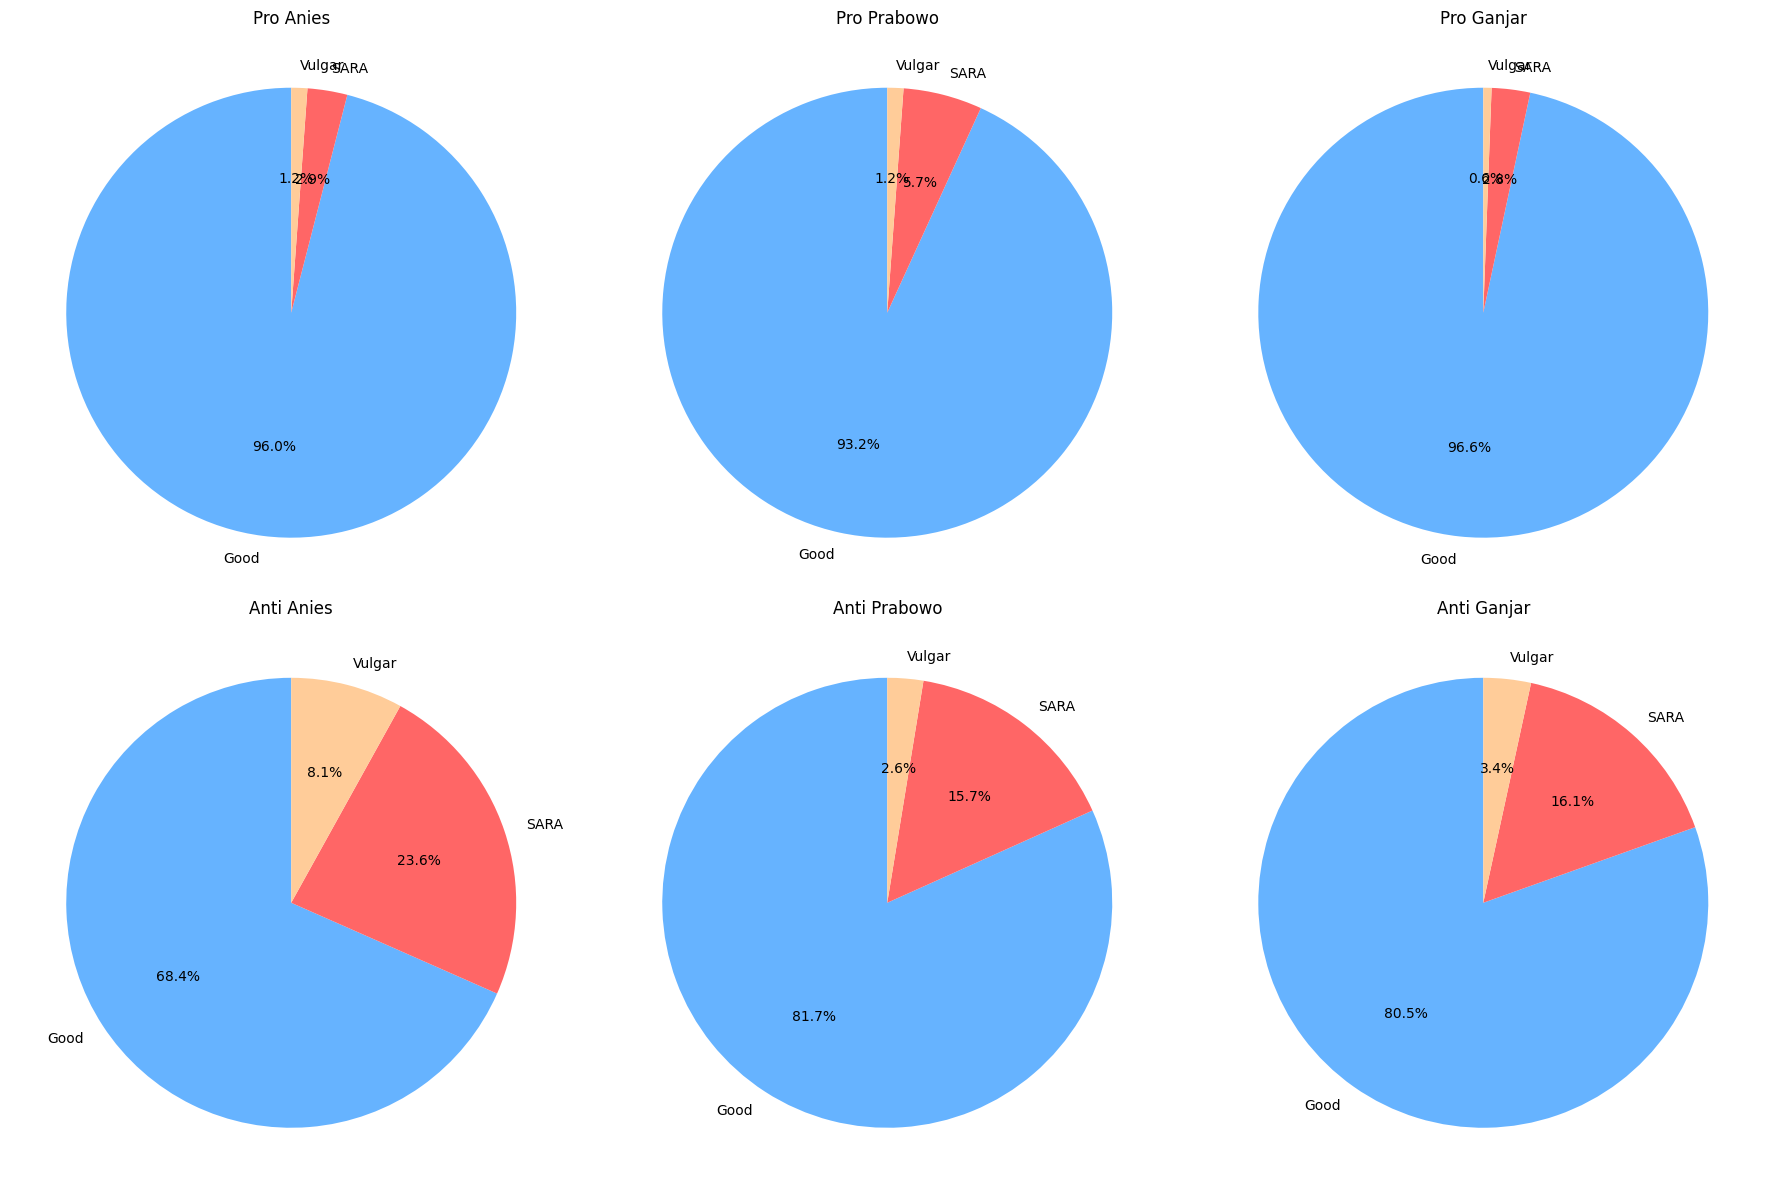

In [ ]:
import matplotlib.pyplot as plt

def plot_pie_chart(ax, df, title):
    # Menghitung jumlah nilai unik di kolom is_civil
    counts = df['is_civil'].value_counts()

    # Menyiapkan label yang sesuai
    labels = {0: 'Good', 1: 'Vulgar', 2: 'SARA'}
    counts.index = counts.index.map(labels)

    # Membuat pie chart
    counts.plot.pie(ax=ax, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff6666', '#ffcc99'])
    ax.set_title(title)
    ax.set_ylabel('')  # Menghapus label y untuk pie chart

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot pie chart untuk setiap DataFrame yang difilter
plot_pie_chart(axes[0, 0], pro_anies, 'Pro Anies')
plot_pie_chart(axes[0, 1], pro_prabowo, 'Pro Prabowo')
plot_pie_chart(axes[0, 2], pro_ganjar, 'Pro Ganjar')
plot_pie_chart(axes[1, 0], anti_anies, 'Anti Anies')
plot_pie_chart(axes[1, 1], anti_prabowo, 'Anti Prabowo')
plot_pie_chart(axes[1, 2], anti_ganjar, 'Anti Ganjar')

plt.tight_layout()
plt.show()

In [ ]:
pro_anies[pro_anies['is_civil'] == 2]

         index                created_at  \
21       16468 2024-01-03 05:11:49+00:00   
124      64223 2024-01-01 09:09:57+00:00   
158      76237 2024-01-04 15:09:26+00:00   
300     141689 2024-01-04 05:58:55+00:00   
550     241145 2024-01-03 11:38:25+00:00   
...        ...                       ...   
16712  9573464 2024-01-05 13:57:15+00:00   
16785  9600210 2024-01-04 23:48:50+00:00   
16800  9611522 2024-01-07 17:31:27+00:00   
16956  9709617 2024-01-05 04:54:49+00:00   
17051  9749611 2024-01-07 14:53:21+00:00   

                                            username    tcode  num_retweets  \
21     @JfjjQ7TF6ac0kjtabkp1u4Dnin93FDCkKqVJ9wPg/zg=    reply            11   
124    @jeqbjB66CMT1zCI7wuxxoNkwWHuZuilUDRxSKCop10U=  mention            16   
158    @GY2G1qISXH4cO9C2sFNRZvi2OrBeGD3jnnXGN4hiz08=  mention            66   
300    @CxXAAFCWgMC67yW8dFMmGdVWQGvbhwa3VsM/u8kgqcc=  mention            31   
550    @0KDLh4gXmMTDTHVrR+ShkMm475w4bmv28APe6uJKHZ8=  mention            20 

# GENERAL

## Date Range Word Cloud

In [ ]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17182 entries, 0 to 17181
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       17182 non-null  int64  
 1   id               17182 non-null  int64  
 2   label            17182 non-null  object 
 3   Timestamp        0 non-null      float64
 4   timestamp        0 non-null      float64
 5   num_retweets     17182 non-null  int64  
 6   content_cleaned  17182 non-null  object 
 7   group            17182 non-null  int64  
 8   anies_stance     17182 non-null  object 
 9   prabowo_stance   17182 non-null  object 
 10  ganjar_stance    17182 non-null  object 
 11  title            17182 non-null  object 
 12  class            17182 non-null  int64  
 13  count            17182 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.8+ MB


In [ ]:
df_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17182 entries, 0 to 17181
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Unnamed: 0                  17182 non-null  int64 
 1   index                       17182 non-null  int64 
 2   created_at                  17182 non-null  object
 3   username                    17123 non-null  object
 4   tcode                       17182 non-null  object
 5   num_retweets                17182 non-null  int64 
 6   type                        17182 non-null  object
 7   frn_cnt                     17182 non-null  int64 
 8   flw_cnt                     17182 non-null  int64 
 9   sts_cnt                     17182 non-null  int64 
 10  loc                         11209 non-null  object
 11  lst_cnt                     17182 non-null  int64 
 12  content                     17182 non-null  object
 13  lang                        17182 non-null  ob

In [ ]:
df_cluster['created_at'] = df_label['created_at']

In [ ]:
df_cluster.head()

   Unnamed: 0  id                                              label  \
0           0   0  Mahfud MD bercerita tentang persahabatannya de...   
1           1   1  Calon presiden Anies Baswedan menyindir ucapan...   
2           2   2  AM1NKeun CIAMIS Pak Anies Rasyid Baswedan seny...   
3           3   3  Prabowo Gibran punya strategi konkret untuk me...   
4           4   4  Program Susu Gratis Tuai Kecaman Prabowo Beber...   

   Timestamp  timestamp  num_retweets  \
0        NaN        NaN            12   
1        NaN        NaN            69   
2        NaN        NaN           102   
3        NaN        NaN           154   
4        NaN        NaN            69   

                                     content_cleaned  group anies_stance  \
0  Mahfud MD bercerita tentang persahabatannya de...      0      Neutral   
1  Calon presiden Anies Baswedan menyindir ucapan...      1          Pro   
2  AM1NKeun CIAMIS Pak Anies Rasyid Baswedan seny...      2          Pro   
3  Prabowo Gibra

In [ ]:
df_cluster['content_cleaned'].value_counts()

content_cleaned
Mahfud MD bercerita tentang persahabatannya dengan mendiang Pendeta Humprey Mereka berdua bersama di DIAN Dialog Antar Iman sebuah gerakan yang didedikasikan untuk persatuan dan kesatuan Bangsa Indonesia Ganjar Mahfud                                                          1
ini dari rakyat Jakarta bu saya cuma nyalurin ketika menyerahkan bantuan untuk lansia betapa besarnya empati Pak Anies Baswedan pada rakyat kecil dan lemah Abdur Celine SayonaraGanjarMahfud Sri Mulyani Luhut                                                                    1
Untuk Kampanye Terbuka pasangan Ganjar Mahfud mengusung tema HAJATAN RAKYAT Mengembalikan pemilu sebagai sarana mendengarkan harapan jutaan rakyat bukan harapan sekeluarga dan sedikit pejabat yang belum tobat                                                                   1
PECAH Lautan Manusia hadiri acara Pesta Rakyat GANJAR MAHFUD di Semarang                                                                                 

In [ ]:
import pandas as pd
# Convert important_dates to a DataFrame
important_dates = [
    ('2024-01-07', 'Debat ke-4'),
    ('2024-01-11', 'Dialog Kadin'),
    ('2024-01-17', 'Dialog KPK'),
    ('2024-01-21', 'Debat ke-5')
]
important_dates_df = pd.DataFrame(important_dates, columns=['date', 'event'])
important_dates_df['date'] = pd.to_datetime(important_dates_df['date'])

# Define date ranges
date_ranges = [
    (None, '2024-01-07'),
    ('2024-01-07', '2024-01-11'),
    ('2024-01-11', '2024-01-17'),
    ('2024-01-17', '2024-01-21'),
    ('2024-01-21', None)
]

# Function to get the cluster with most retweets in a date range
def get_top_cluster(df, start_date, end_date):
    if start_date is not None:
        df = df[df['created_at'] >= start_date]
    if end_date is not None:
        df = df[df['created_at'] < end_date]
    top_cluster = df.groupby('class')['num_retweets'].sum().idxmax()
    return top_cluster

# Analyze clusters for each date range
results = []
for start_date, end_date in date_ranges:
    top_cluster = get_top_cluster(df_cluster, start_date, end_date)
    date_range_str = f"{start_date} to {end_date}"
    results.append((date_range_str, top_cluster))

# Convert results to DataFrame and display
results_df = pd.DataFrame(results, columns=['Date Range', 'Top Cluster'])

In [ ]:
results_df

                 Date Range  Top Cluster
0        None to 2024-01-07         6724
1  2024-01-07 to 2024-01-11         4523
2  2024-01-11 to 2024-01-17         6724
3  2024-01-17 to 2024-01-21         6724
4        2024-01-21 to None         6724

In [ ]:
df_cluster[df_cluster['class'] == 6724]

       Unnamed: 0     id                                              label  \
1               1      1  Calon presiden Anies Baswedan menyindir ucapan...   
17             17     17  Acara Desak Anies di Sumbar Tiba tiba Pindah L...   
19             19     19  Respon pak Anies Baswedan soal izin acara yang...   
44             44     44  Relawan Sobat Anies Cipatat Sampai malam pun t...   
47             47     47  Jadwal Kampanye pak Anies besok di Tasik dan C...   
...           ...    ...                                                ...   
17067       17067  17067  Alhamdulillah Dukungan terus menguat 300 Penga...   
17086       17086  17086  Capres lain baru akan akan dan akan melakukan ...   
17102       17102  17102  Memanas ihwal pembagian bantuan sosial bansos ...   
17113       17113  17113  Abah online Meroket Figur Pak Anies Semakin Po...   
17146       17146  17146  Abah Anies dan Gus Imin langsung Live Tiktok d...   

       Timestamp  timestamp  num_retweets  \
1     

In [ ]:
df_cluster[df_cluster['class'] == 6724]

       Unnamed: 0     id                                              label  \
1               1      1  Calon presiden Anies Baswedan menyindir ucapan...   
17             17     17  Acara Desak Anies di Sumbar Tiba tiba Pindah L...   
19             19     19  Respon pak Anies Baswedan soal izin acara yang...   
44             44     44  Relawan Sobat Anies Cipatat Sampai malam pun t...   
47             47     47  Jadwal Kampanye pak Anies besok di Tasik dan C...   
...           ...    ...                                                ...   
17067       17067  17067  Alhamdulillah Dukungan terus menguat 300 Penga...   
17086       17086  17086  Capres lain baru akan akan dan akan melakukan ...   
17102       17102  17102  Memanas ihwal pembagian bantuan sosial bansos ...   
17113       17113  17113  Abah online Meroket Figur Pak Anies Semakin Po...   
17146       17146  17146  Abah Anies dan Gus Imin langsung Live Tiktok d...   

       Timestamp  timestamp  num_retweets  \
1     

In [ ]:
df_cluster['class'].value_counts()

class
6724    2143
4268    1044
5503     823
1834     650
1895     571
        ... 
3001       1
3000       1
2999       1
2998       1
8892       1
Name: count, Length: 8893, dtype: int64

In [ ]:
import pandas as pd


# Convert important_dates to a DataFrame
important_dates = [
    ('2024-01-07', 'Debat ke-4'),
    ('2024-01-11', 'Dialog Kadin'),
    ('2024-01-17', 'Dialog KPK'),
    ('2024-01-21', 'Debat ke-5')
]
important_dates_df = pd.DataFrame(important_dates, columns=['date', 'event'])
important_dates_df['date'] = pd.to_datetime(important_dates_df['date'])

# Define date ranges
date_ranges = [
    (None, '2024-01-07'),
    ('2024-01-07', '2024-01-11'),
    ('2024-01-11', '2024-01-17'),
    ('2024-01-17', '2024-01-21'),
    ('2024-01-21', None)
]

# Function to get the cluster with most count in a date range
def get_top_cluster(df, start_date, end_date):
    if start_date is not None:
        df = df[df['created_at'] >= start_date]
    if end_date is not None:
        df = df[df['created_at'] < end_date]
    top_cluster = df['class'].value_counts().idxmax()
    return top_cluster

# Analyze clusters for each date range
results = []
for start_date, end_date in date_ranges:
    top_cluster = get_top_cluster(df_cluster, start_date, end_date)
    date_range_str = f"{start_date} to {end_date}"
    results.append((date_range_str, top_cluster))

# Convert results to DataFrame and display
results_df = pd.DataFrame(results, columns=['Date Range', 'Top Cluster'])

In [ ]:
results_df

                 Date Range  Top Cluster
0        None to 2024-01-07         6724
1  2024-01-07 to 2024-01-11         4520
2  2024-01-11 to 2024-01-17         6724
3  2024-01-17 to 2024-01-21         6724
4        2024-01-21 to None         6724

In [ ]:
import pandas as pd
# Convert important_dates to a DataFrame
important_dates = [
    ('2024-01-07', 'Debat ke-4'),
    ('2024-01-11', 'Dialog Kadin'),
    ('2024-01-17', 'Dialog KPK'),
    ('2024-01-21', 'Debat ke-5')
]
important_dates_df = pd.DataFrame(important_dates, columns=['date', 'event'])
important_dates_df['date'] = pd.to_datetime(important_dates_df['date'])

# Define date ranges
date_ranges = [
    (None, '2024-01-07'),
    ('2024-01-07', '2024-01-11'),
    ('2024-01-11', '2024-01-17'),
    ('2024-01-17', '2024-01-21'),
    ('2024-01-21', None)
]

# Function to get the top-5 clusters with most counts in a date range
def get_top_clusters(df, start_date, end_date):
    if start_date is not None:
        df = df[df['created_at'] >= start_date]
    if end_date is not None:
        df = df[df['created_at'] < end_date]
    top_clusters = df['class'].value_counts().head(5)
    return top_clusters

# Analyze clusters for each date range
results = []
for start_date, end_date in date_ranges:
    top_clusters = get_top_clusters(df_cluster, start_date, end_date)
    date_range_str = f"{start_date} to {end_date}"
    for cluster, count in top_clusters.items():
        results.append((date_range_str, cluster, count))

# Convert results to DataFrame and display
results_df = pd.DataFrame(results, columns=['Date Range', 'Cluster', 'Count'])

In [ ]:
results_df

                  Date Range  Cluster  Count
0         None to 2024-01-07     6724    323
1         None to 2024-01-07     4268    174
2         None to 2024-01-07     5503    145
3         None to 2024-01-07     1895    132
4         None to 2024-01-07      974    104
5   2024-01-07 to 2024-01-11     4520    221
6   2024-01-07 to 2024-01-11     6724    196
7   2024-01-07 to 2024-01-11     4268    168
8   2024-01-07 to 2024-01-11     7984    145
9   2024-01-07 to 2024-01-11     5503    120
10  2024-01-11 to 2024-01-17     6724    533
11  2024-01-11 to 2024-01-17     4268    225
12  2024-01-11 to 2024-01-17     1895    157
13  2024-01-11 to 2024-01-17     5503    133
14  2024-01-11 to 2024-01-17     7984     68
15  2024-01-17 to 2024-01-21     6724    389
16  2024-01-17 to 2024-01-21     5503    150
17  2024-01-17 to 2024-01-21     4268    149
18  2024-01-17 to 2024-01-21     1834     99
19  2024-01-17 to 2024-01-21       15     75
20        2024-01-21 to None     6724    702
21        

In [ ]:
!pip install nltk wordcloud matplotlib

In [ ]:
from nltk.corpus import stopwords
import nltk

# Download the stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Define Indonesian stopwords
indonesian_stopwords = set(stopwords.words('indonesian'))

# Function to remove stopwords
def remove_stopwords(text, stopwords):
  text = text.replace(" yg ", " ")
  return ' '.join([word for word in text.split() if word.lower() not in stopwords])

# Remove stopwords from 'content'
df_cluster['content_stop'] = df_cluster['content_cleaned'].apply(lambda x: remove_stopwords(x, indonesian_stopwords))

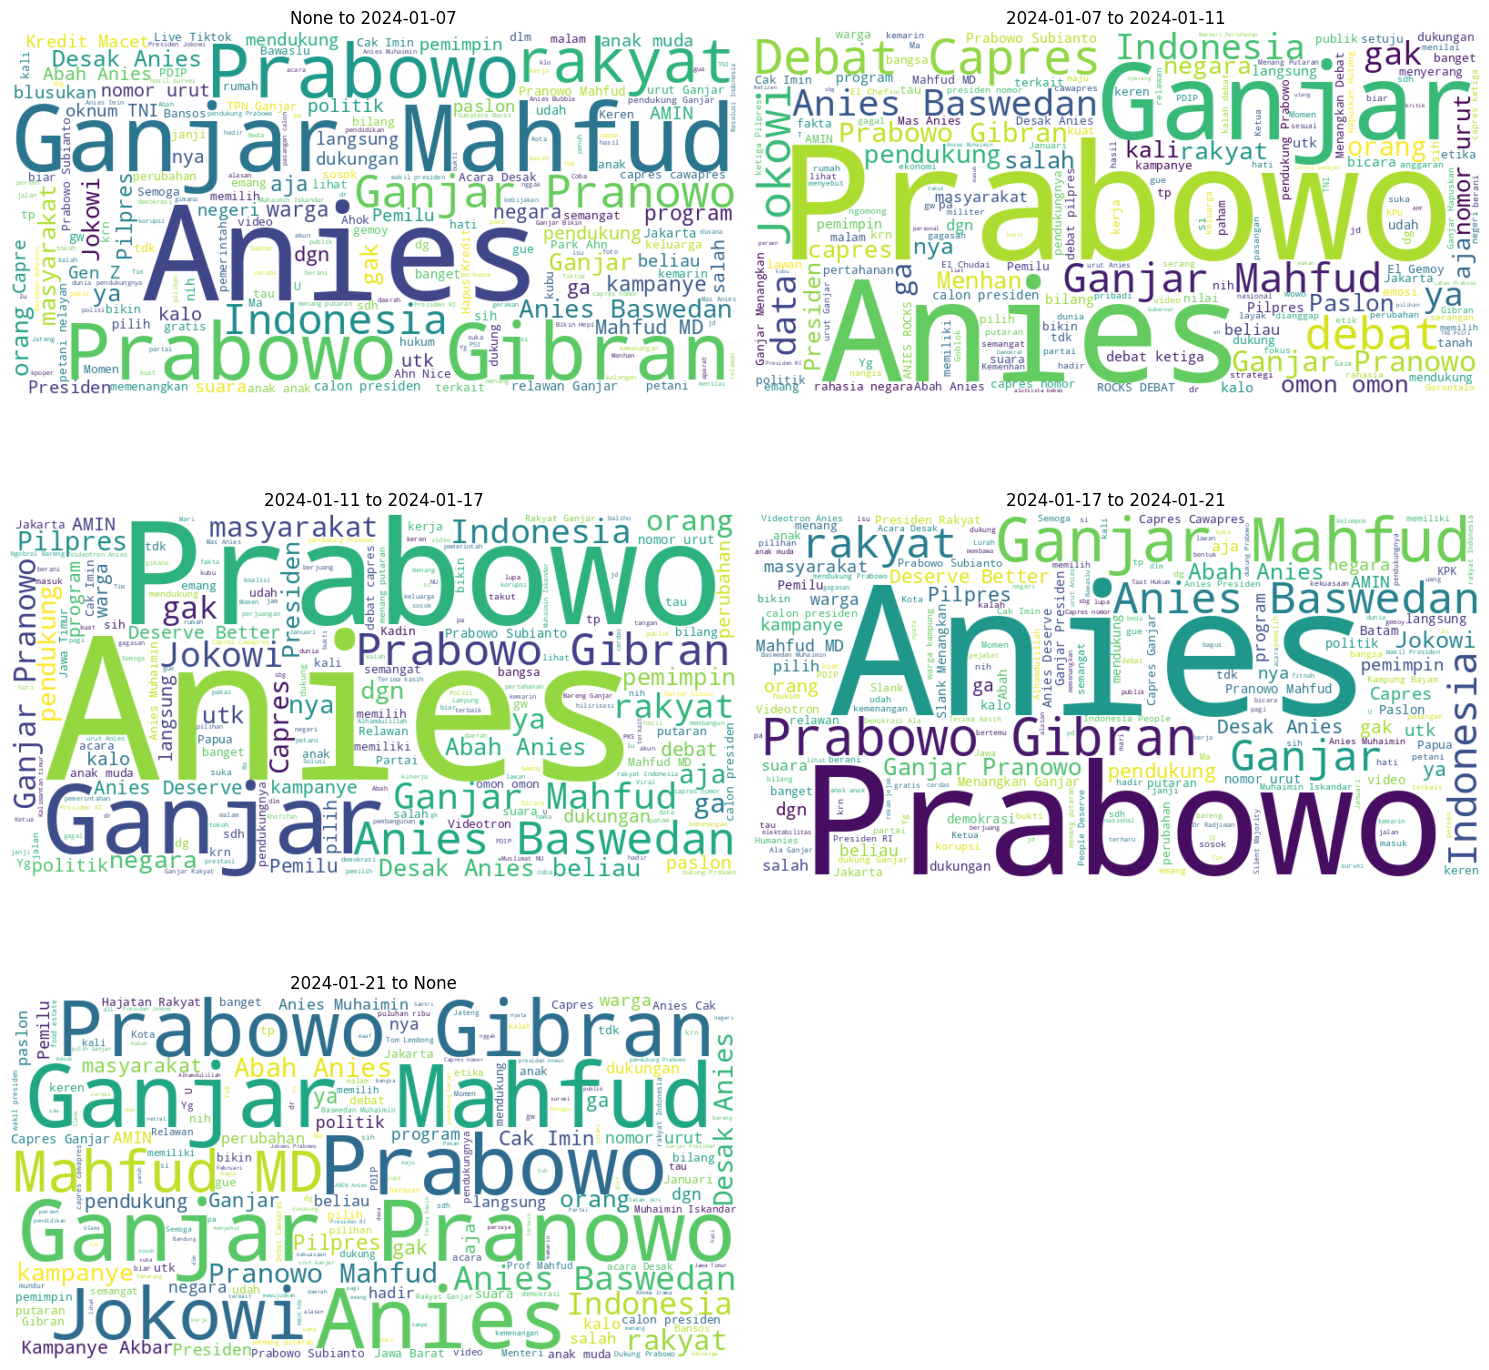

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# Convert important_dates to a DataFrame
important_dates = [
    ('2024-01-07', 'Debat ke-4'),
    ('2024-01-11', 'Dialog Kadin'),
    ('2024-01-17', 'Dialog KPK'),
    ('2024-01-21', 'Debat ke-5')
]
important_dates_df = pd.DataFrame(important_dates, columns=['date', 'event'])
important_dates_df['date'] = pd.to_datetime(important_dates_df['date'])

# Define date ranges
date_ranges = [
    (None, '2024-01-07'),
    ('2024-01-07', '2024-01-11'),
    ('2024-01-11', '2024-01-17'),
    ('2024-01-17', '2024-01-21'),
    ('2024-01-21', None)
]

# Function to generate word cloud for a date range
def generate_word_cloud(df, start_date, end_date, ax):
    if start_date is not None:
        df = df[df['created_at'] >= start_date]
    if end_date is not None:
        df = df[df['created_at'] < end_date]

    text = ' '.join(df['content_stop'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')

# Plot word clouds for each date range
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, (start_date, end_date) in enumerate(date_ranges):
    ax = axes[i]
    date_range_str = f"{start_date} to {end_date}"
    generate_word_cloud(df_cluster, start_date, end_date, ax)
    ax.set_title(date_range_str)

# Remove any empty subplots
for j in range(len(date_ranges), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
df_anies_positive = df_cluster[df_cluster['anies_stance'] == 'Pro']
df_anies_negative = df_cluster[df_cluster['anies_stance'] == 'Anti']
df_ganjar_positive = df_cluster[df_cluster['ganjar_stance'] == 'Pro']
df_ganjar_negative = df_cluster[df_cluster['ganjar_stance'] == 'Anti']
df_prabowo_positive = df_cluster[df_cluster['prabowo_stance'] == 'Pro']
df_prabowo_negative = df_cluster[df_cluster['prabowo_stance'] == 'Anti']

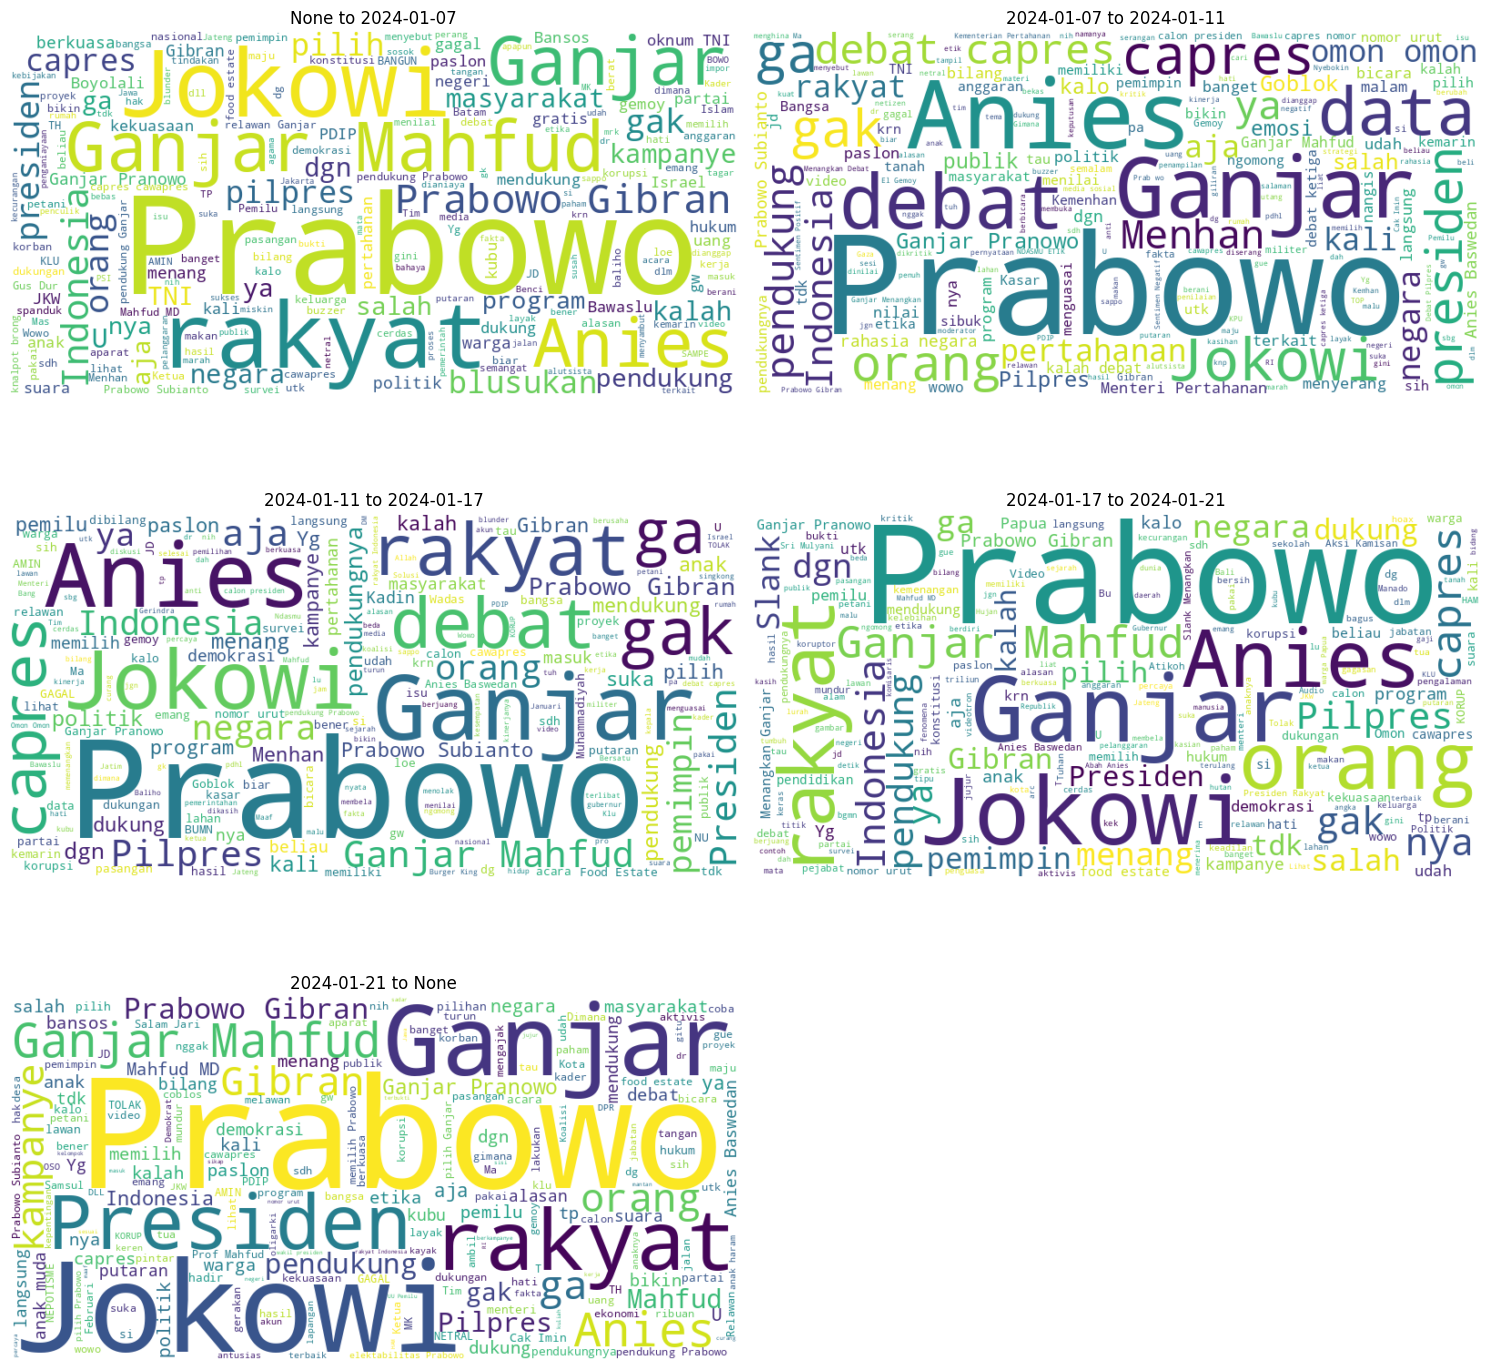

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert important_dates to a DataFrame
important_dates = [
    ('2024-01-07', 'Debat ke-4'),
    ('2024-01-11', 'Dialog Kadin'),
    ('2024-01-17', 'Dialog KPK'),
    ('2024-01-21', 'Debat ke-5')
]
important_dates_df = pd.DataFrame(important_dates, columns=['date', 'event'])
important_dates_df['date'] = pd.to_datetime(important_dates_df['date'])

# Define date ranges
date_ranges = [
    (None, '2024-01-07'),
    ('2024-01-07', '2024-01-11'),
    ('2024-01-11', '2024-01-17'),
    ('2024-01-17', '2024-01-21'),
    ('2024-01-21', None)
]

# Function to generate word cloud for a date range
def generate_word_cloud(df, start_date, end_date, ax):
    if start_date is not None:
        df = df[df['created_at'] >= start_date]
    if end_date is not None:
        df = df[df['created_at'] < end_date]

    text = ' '.join(df['content_stop'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')

# Plot word clouds for each date range
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, (start_date, end_date) in enumerate(date_ranges):
    ax = axes[i]
    date_range_str = f"{start_date} to {end_date}"
    generate_word_cloud(df_prabowo_negative, start_date, end_date, ax)
    ax.set_title(date_range_str)

# Remove any empty subplots
for j in range(len(date_ranges), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Top Cluster Contra Date Range

In [ ]:
df_anies_cluster = pd.read_csv(f"{DATA_DIR}/anies_node_details_925_pred.csv")
df_prabowo_cluster = pd.read_csv(f"{DATA_DIR}/prabowo_node_details_925_pred.csv")
df_ganjar_cluster = pd.read_csv(f"{DATA_DIR}/ganjar_node_details_925_pred.csv")

In [ ]:
df_neg_anies_cluster = df_anies_cluster[df_anies_cluster['anies_pred'] == 'Kontra']
df_neg_prabowo_cluster = df_prabowo_cluster[df_prabowo_cluster['prabowo_pred'] == 'Kontra']
df_neg_ganjar_cluster = df_ganjar_cluster[df_ganjar_cluster['ganjar_pred'] == 'Kontra']

In [ ]:
df_neg_anies_cluster.head(1)

,Timestamp,num_retweets,content_cleaned,anies_pred,prabowo_pred,ganjar_pred,is_civil_pred,title,id,degree,class,class_size
0,2024-01-04T10:03:01Z,69,Calon presiden Anies Baswedan menyindir ucapan...,Kontra,Netral,Netral,Civil,Tweet 1: Calon presiden Anies Baswedan menyind...,1,37,6724,2143.0


In [ ]:
import pandas as pd


# Convert important_dates to a DataFrame
important_dates = [
    ('2024-01-07', 'Debat ke-4'),
    ('2024-01-11', 'Dialog Kadin'),
    ('2024-01-17', 'Dialog KPK'),
    ('2024-01-21', 'Debat ke-5')
]
important_dates_df = pd.DataFrame(important_dates, columns=['date', 'event'])
important_dates_df['date'] = pd.to_datetime(important_dates_df['date'])

# Define date ranges
date_ranges = [
    (None, '2024-01-07'),
    ('2024-01-07', '2024-01-11'),
    ('2024-01-11', '2024-01-17'),
    ('2024-01-17', '2024-01-21'),
    ('2024-01-21', None)
]

# Function to get the cluster with most count in a date range
def get_top_cluster(df, start_date, end_date):
    if start_date is not None:
        df = df[df['Timestamp'] >= start_date]
    if end_date is not None:
        df = df[df['Timestamp'] < end_date]
    top_cluster = df['class'].value_counts().idxmax()
    return top_cluster

# Analyze clusters for each date range
results = []
for start_date, end_date in date_ranges:
    top_cluster = get_top_cluster(df_neg_ganjar_cluster, start_date, end_date)
    date_range_str = f"{start_date} to {end_date}"
    results.append((date_range_str, top_cluster))

# Convert results to DataFrame and display
results_df = pd.DataFrame(results, columns=['Date Range', 'Top Cluster'])

In [ ]:
results_df

                 Date Range  Top Cluster
0        None to 2024-01-07           15
1  2024-01-07 to 2024-01-11           15
2  2024-01-11 to 2024-01-17           15
3  2024-01-17 to 2024-01-21           15
4        2024-01-21 to None           15

In [ ]:
df_neg_ganjar_cluster[df_neg_ganjar_cluster['class'] == 15]

## Civility Filtered

### Plot 1

In [ ]:
df_anies_cluster = pd.read_csv(f"{DATA_DIR}/anies_node_details_925_pred.csv")
df_prabowo_cluster = pd.read_csv(f"{DATA_DIR}/prabowo_node_details_925_pred.csv")
df_ganjar_cluster = pd.read_csv(f"{DATA_DIR}/ganjar_node_details_925_pred.csv")

In [ ]:
df_anies_cluster.head(1)

,Timestamp,num_retweets,content_cleaned,anies_pred,prabowo_pred,ganjar_pred,is_civil_pred,title,id
0,2024-01-04T10:03:01Z,69,Calon presiden Anies Baswedan menyindir ucapan...,Kontra,Netral,Netral,Civil,Tweet 1: Calon presiden Anies Baswedan menyind...,1


In [ ]:
df_anies_cluster['is_civil_pred'].value_counts()

is_civil_pred
Civil     6362
Vulgar     555
SARA       214
Name: count, dtype: int64

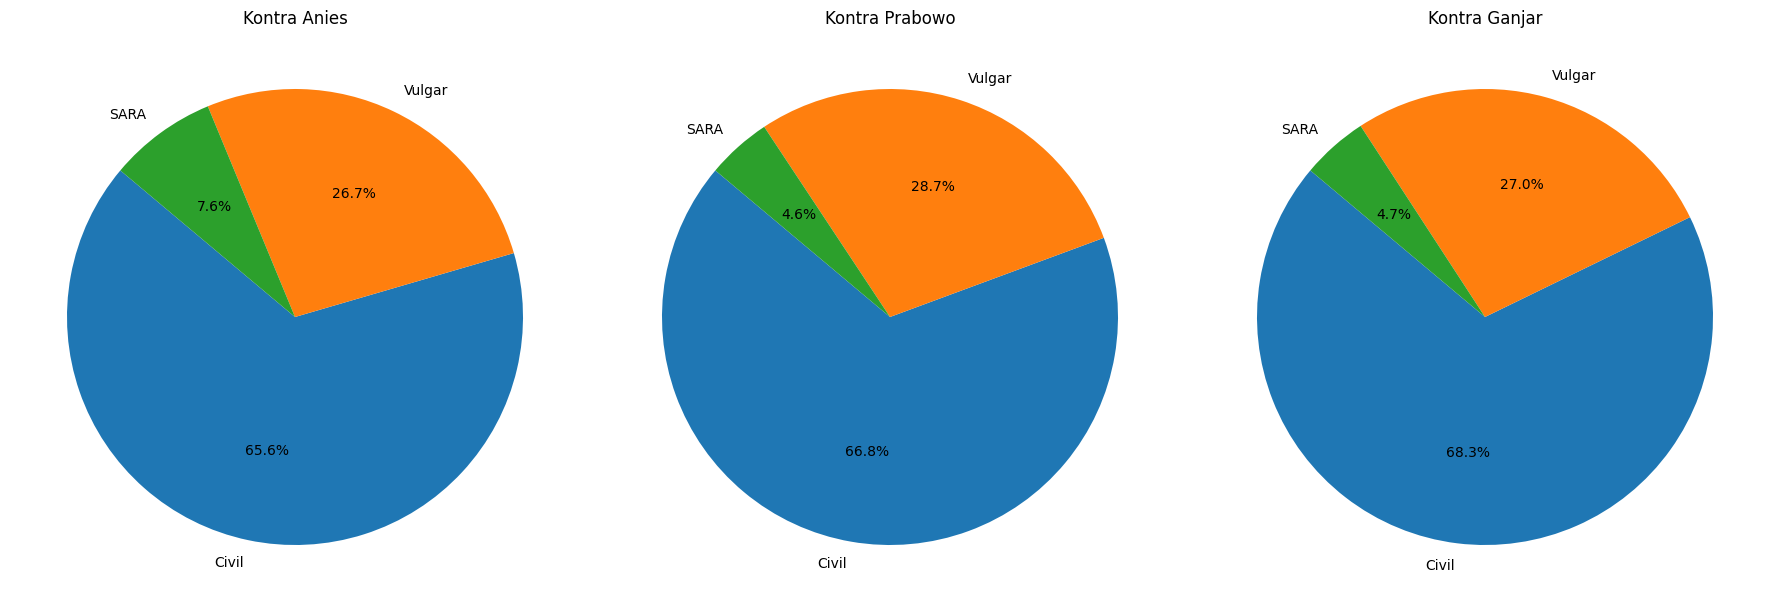

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_anies_cluster, df_prabowo_cluster, and df_ganjar_cluster are your DataFrames

# Function to plot pie chart for a given DataFrame and title
def plot_pie_chart(ax, df, candidate_name):
    is_civil_counts = df['is_civil_pred'].value_counts()
    ax.pie(is_civil_counts, labels=is_civil_counts.index, autopct='%1.1f%%', startangle=140)
    ax.set_title(f'{candidate_name}')

# Filter DataFrames
df_anies_kontra = df_anies_cluster[df_anies_cluster['anies_pred'] == 'Kontra']
df_prabowo_kontra = df_prabowo_cluster[df_prabowo_cluster['prabowo_pred'] == 'Kontra']
df_ganjar_kontra = df_ganjar_cluster[df_ganjar_cluster['ganjar_pred'] == 'Kontra']

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot each pie chart in a subplot
plot_pie_chart(axs[0], df_anies_kontra, 'Kontra Anies')
plot_pie_chart(axs[1], df_prabowo_kontra, 'Kontra Prabowo')
plot_pie_chart(axs[2], df_ganjar_kontra, 'Kontra Ganjar')

# Show the plots
plt.tight_layout()
plt.show()

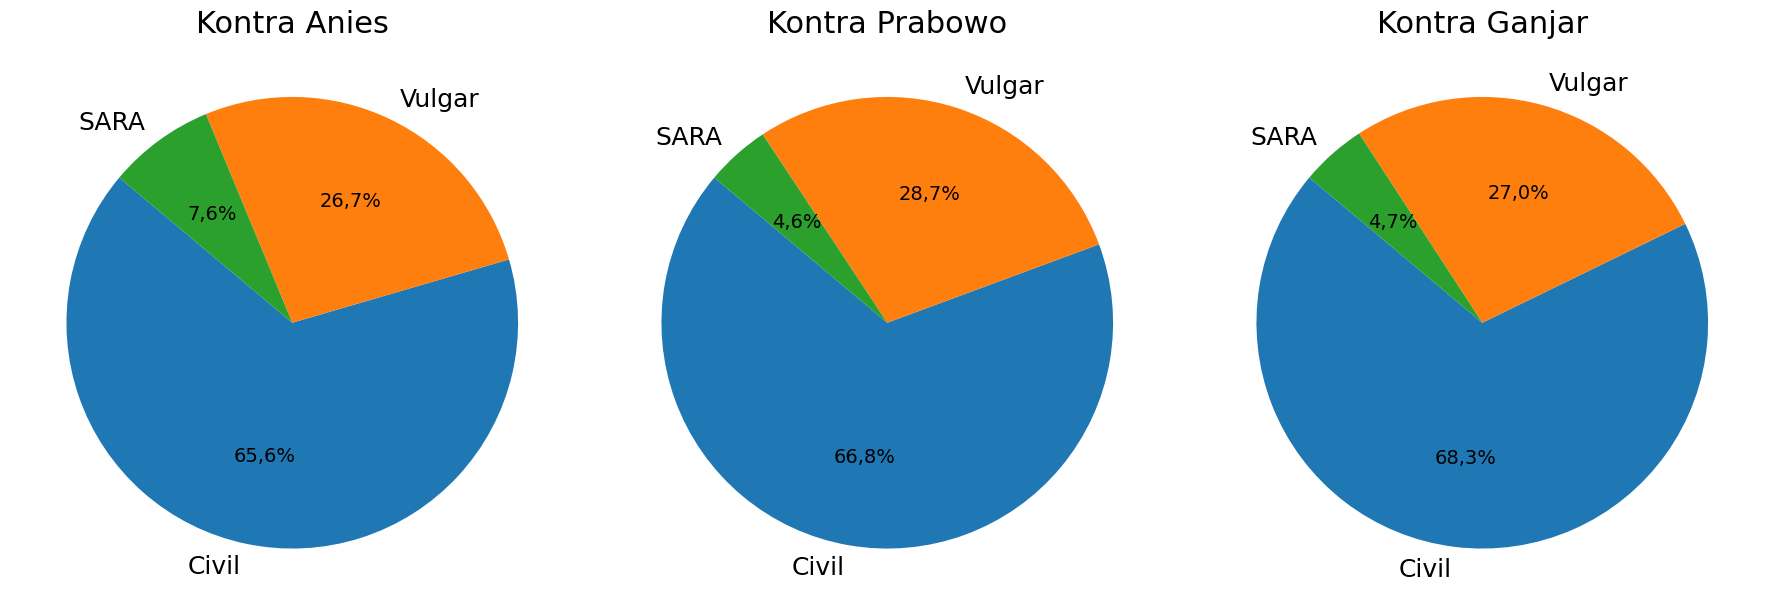

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_anies_cluster, df_prabowo_cluster, and df_ganjar_cluster are your DataFrames

# Custom function to format percentage with commas
def comma_autopct(pct):
    return ('%1.1f' % pct).replace('.', ',') + '%'

# Function to plot pie chart for a given DataFrame and title
def plot_pie_chart(ax, df, candidate_name):
    is_civil_counts = df['is_civil_pred'].value_counts()
    wedges, texts, autotexts = ax.pie(is_civil_counts, labels=is_civil_counts.index, autopct=comma_autopct, startangle=140, textprops={'fontsize': 14})
    for text in texts:
        text.set_fontsize(18)
    for autotext in autotexts:
        autotext.set_fontsize(14)
    ax.set_title(f'{candidate_name}', fontsize=22)

# Filter DataFrames
df_anies_kontra = df_anies_cluster[df_anies_cluster['anies_pred'] == 'Kontra']
df_prabowo_kontra = df_prabowo_cluster[df_prabowo_cluster['prabowo_pred'] == 'Kontra']
df_ganjar_kontra = df_ganjar_cluster[df_ganjar_cluster['ganjar_pred'] == 'Kontra']

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot each pie chart in a subplot
plot_pie_chart(axs[0], df_anies_kontra, 'Kontra Anies')
plot_pie_chart(axs[1], df_prabowo_kontra, 'Kontra Prabowo')
plot_pie_chart(axs[2], df_ganjar_kontra, 'Kontra Ganjar')

# Show the plots
plt.tight_layout()
plt.show()

Distribusi label civility pada cuitan yang kontra terhadap masing-masing tokoh menunjukkan pola yang menarik. Anies mendapatkan proporsi tertinggi dari cuitan yang mengandung konten SARA (7.6%) dibandingkan dengan Prabowo (4.6%) dan Ganjar (4.7%), yang dapat menunjukkan bahwa isu-isu sensitif terkait identitas sering muncul dalam kritik terhadap Anies. Meskipun demikian, cuitan vulgar lebih banyak diarahkan kepada Prabowo (28.7%), dibandingkan dengan Ganjar (27%) dan Anies (26.7%). Masih banyaknya cuitan yang non-civil (SARA atau Vulgar) menunjukkan bahwa diskusi politik di media sosial masih sering diwarnai oleh bahasa yang tidak pantas dan potensi memecah belah. Oleh karena itu, tim kampanye masing-masing paslon perlu berperan aktif dalam mengarahkan relawan mereka untuk menjaga etika dalam berkomunikasi dan tidak menodai proses demokrasi dengan cuitan yang tidak pantas.

In [ ]:
import pandas as pd

# Assuming df_cluster is your DataFrame

# Step 1: Calculate the total number of entries for each class
total_counts = df_cluster['class'].value_counts()

# Step 2: Calculate the number of SARA and Vulgar entries for each class
sara_counts = df_cluster[df_cluster['is_civil'] == 'SARA']['class'].value_counts()
vulgar_counts = df_cluster[df_cluster['is_civil'] == 'Vulgar']['class'].value_counts()

# Step 3: Calculate the proportion of SARA and Vulgar entries within each class
sara_proportions = sara_counts / total_counts
vulgar_proportions = vulgar_counts / total_counts

# Step 4: Identify the class with the highest proportion for both SARA and Vulgar
most_sara_class = sara_proportions.idxmax()
most_vulgar_class = vulgar_proportions.idxmax()

most_sara_proportion = sara_proportions.max()
most_vulgar_proportion = vulgar_proportions.max()

most_sara_class, most_sara_proportion, most_vulgar_class, most_vulgar_proportion

NameError: name 'df_cluster' is not defined

## Time Line Civility

In [48]:
df_anies_cluster = pd.read_csv(f"{DATA_DIR}/anies_node_details_925_pred.csv")
df_prabowo_cluster = pd.read_csv(f"{DATA_DIR}/prabowo_node_details_925_pred.csv")
df_ganjar_cluster = pd.read_csv(f"{DATA_DIR}/ganjar_node_details_925_pred.csv")

In [49]:
def convert_sopan(before):
  if before == 'Civil':
    return 'Sopan'
  else:
    return before

df_anies_cluster['is_civil_pred'] = df_anies_cluster['is_civil_pred'].apply(convert_sopan)
df_prabowo_cluster['is_civil_pred'] = df_prabowo_cluster['is_civil_pred'].apply(convert_sopan)
df_ganjar_cluster['is_civil_pred'] = df_ganjar_cluster['is_civil_pred'].apply(convert_sopan)

In [50]:
df_anies_cluster.head()

              Timestamp  num_retweets  \
0  2024-01-04T10:03:01Z            69   
1  2024-01-04T10:03:52Z           102   
2  2024-01-04T10:11:24Z            23   
3  2024-01-01T21:35:03Z            42   
4  2024-01-01T21:55:25Z            14   

                                     content_cleaned anies_pred prabowo_pred  \
0  Calon presiden Anies Baswedan menyindir ucapan...     Kontra       Netral   
1  AM1NKeun CIAMIS Pak Anies Rasyid Baswedan seny...        Pro       Netral   
2  Kritik Zulhas Soal Bansos dari Jokowi Anies It...     Kontra       Netral   
3  Baca komen2 warga Tiktok bikin terharu Abah An...        Pro       Netral   
4  Korupsi KPK Etika Luar biasa penjelasan capres...        Pro       Netral   

  ganjar_pred is_civil_pred  \
0      Netral         Sopan   
1      Netral         Sopan   
2      Netral         Sopan   
3      Netral         Sopan   
4      Netral         Sopan   

                                               title  id  degree  class  \
0  Tweet 1

In [15]:
df_anies_cluster['is_civil_pred'].value_counts()

is_civil_pred
Sopan     6362
Vulgar     555
SARA       214
Name: count, dtype: int64

In [6]:
df_anies_cluster.head(1)

,Timestamp,num_retweets,content_cleaned,anies_pred,prabowo_pred,ganjar_pred,is_civil_pred,title,id,degree,class,class_size
0,2024-01-04T10:03:01Z,69,Calon presiden Anies Baswedan menyindir ucapan...,Kontra,Netral,Netral,Civil,Tweet 1: Calon presiden Anies Baswedan menyind...,1,37,6724,2143.0


Dapat terlihat bahwa setelah debat ke

In [ ]:
df

<ipython-input-24-1fa648560b8a>:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['day'] = df['Timestamp'].dt.to_period('D')
<ipython-input-24-1fa648560b8a>:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['day'] = df['Timestamp'].dt.to_period('D')
<ipython-input-24-1fa648560b8a>:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['day'] = df['Timestamp'].dt.to_period('D')


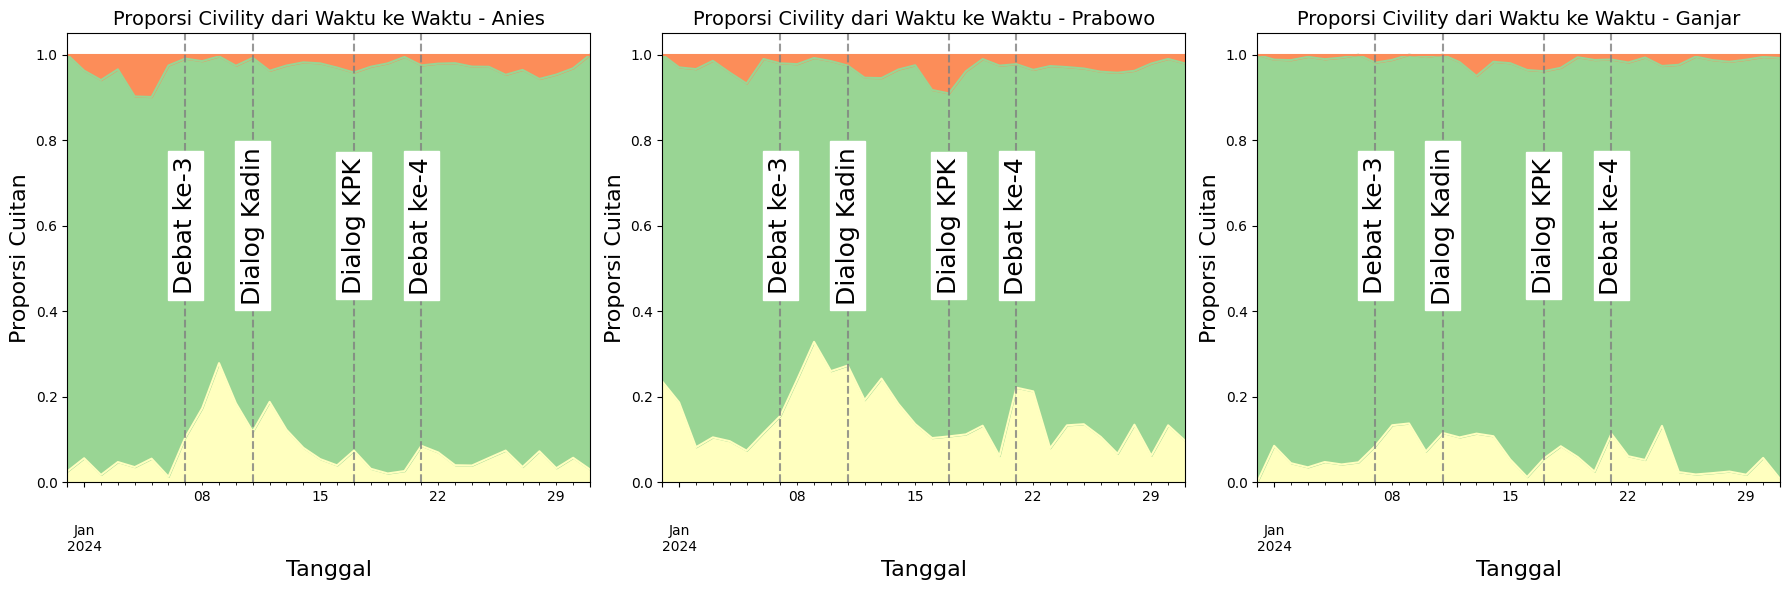

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_anies_cluster, df_prabowo_cluster, and df_ganjar_cluster are your DataFrames

# Function to plot stacked area chart with important dates
def plot_stacked_area_with_dates(ax, df, candidate_name, important_dates):
    # Convert 'Timestamp' to datetime if it is not already
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

    # Group by day and civility label
    df['day'] = df['Timestamp'].dt.to_period('D')
    grouped = df.groupby(['day', 'is_civil_pred']).size().unstack(fill_value=0)

    # Calculate proportions
    proportions = grouped.div(grouped.sum(axis=1), axis=0)

    # Pivot the DataFrame
    pivoted = proportions.reset_index().set_index('day')

    # Define the color map

    #fc8d59
    #ffffbf
    #99d594
    civility_colors = {
        'SARA': '#fc8d59',  # New color for SARA
        'Vulgar': '#ffffbf',  # New color for Vulgar
        'Sopan': '#99d594'   # New color for Civil
    }

    # Reorder the columns
    pivoted = pivoted[['Vulgar', 'Sopan', 'SARA']]

    # Plot stacked area chart
    pivoted.plot(kind='area', stacked=True, color=[civility_colors[col] for col in pivoted.columns], ax=ax)

    # Add important dates
    for date, label in important_dates:
        ax.axvline(pd.to_datetime(date), color='gray', linestyle='--', alpha=0.8)  # Add a vertical line for each date
        ax.text(pd.to_datetime(date), 0.6, label, rotation=90, va='center', ha='center', fontsize=18, backgroundcolor='white')

    # Customize the plot
    ax.set_title(f'Proporsi Civility dari Waktu ke Waktu - {candidate_name}', fontsize=14)
    ax.set_xlabel('Tanggal', fontsize=16)
    ax.set_ylabel('Proporsi Cuitan', fontsize=16)
    # Legend removed
    # ax.legend(title='Civility', loc='lower right', fontsize=12, title_fontsize=12)
    ax.get_legend().remove()

# Important dates
important_dates = [('2024-01-07', 'Debat ke-3'),
                   ('2024-01-11', 'Dialog Kadin'),
                   ('2024-01-17', 'Dialog KPK'),
                   ('2024-01-21', 'Debat ke-4')]

# Create subplots for each candidate
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot for Anies
plot_stacked_area_with_dates(axs[0], df_anies_cluster, 'Anies', important_dates)

# Plot for Prabowo
plot_stacked_area_with_dates(axs[1], df_prabowo_cluster, 'Prabowo', important_dates)

# Plot for Ganjar
plot_stacked_area_with_dates(axs[2], df_ganjar_cluster, 'Ganjar', important_dates)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

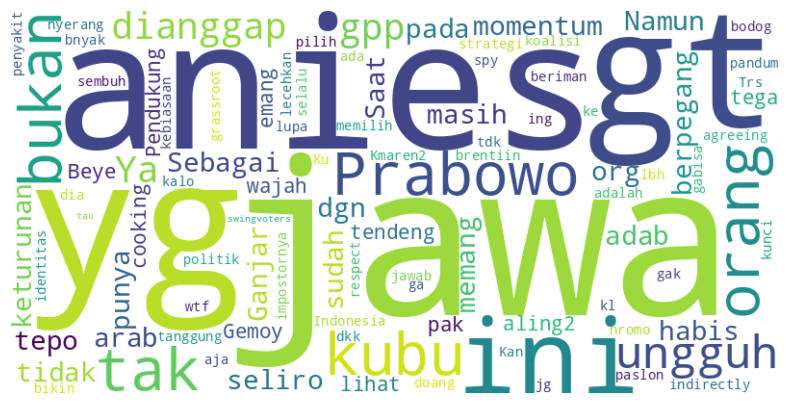

In [73]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert TimeStamp column to datetime
df_anies_cluster['Timestamp'] = pd.to_datetime(df_anies_cluster['Timestamp'])

# Filter the dataframe for the dates January 8, 2024, to January 10, 2024
# Define the precise start and end datetimes
start_date = '2024-01-07 21:00:00'
end_date = '2024-01-08 23:59:59'
filtered_df = df_anies_cluster[(df_anies_cluster['Timestamp'] >= start_date) & (df_anies_cluster['Timestamp'] <= end_date)]
filtered_df = filtered_df[filtered_df['is_civil_pred'] == 'SARA']

# Combine all the text from the ContentCleaned column
combined_text = ' '.join(filtered_df['content_cleaned'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove axis
plt.show()

In [71]:
filtered_df

                     Timestamp  num_retweets  \
3394 2024-01-08 04:04:59+00:00            28   
3398 2024-01-08 12:55:14+00:00           159   
3416 2024-01-08 09:16:47+00:00           443   
3421 2024-01-08 03:37:22+00:00            20   
3422 2024-01-08 03:43:42+00:00            71   
3426 2024-01-08 08:19:15+00:00            13   
3428 2024-01-08 08:23:27+00:00           102   
3440 2024-01-08 13:57:36+00:00           100   
3459 2024-01-08 02:49:40+00:00            27   
3460 2024-01-08 02:50:23+00:00            19   
3473 2024-01-08 22:59:05+00:00            13   
3485 2024-01-08 23:07:06+00:00            90   
3489 2024-01-07 23:29:21+00:00            71   
3496 2024-01-08 12:13:49+00:00            15   
3512 2024-01-08 09:02:57+00:00            33   
3578 2024-01-08 05:39:57+00:00            21   
3599 2024-01-07 22:33:55+00:00            48   
3603 2024-01-07 23:17:17+00:00            14   
3607 2024-01-08 07:20:46+00:00            14   
3610 2024-01-08 15:47:05+00:00          

In [72]:
filtered_df['is_civil_pred'].value_counts()

is_civil_pred
Vulgar    52
SARA       4
Name: count, dtype: int64

In [ ]:
df_anies_cluster.head(1)

,Timestamp,num_retweets,content_cleaned,anies_pred,prabowo_pred,ganjar_pred,is_civil_pred,title,id,degree,class,class_size
0,2024-01-04T10:03:01Z,69,Calon presiden Anies Baswedan menyindir ucapan...,Kontra,Netral,Netral,Civil,Tweet 1: Calon presiden Anies Baswedan menyind...,1,37,6724,2143.0


In [ ]:
import pandas as pd

# Convert 'Timestamp' column to datetime
df_anies_cluster['Timestamp'] = pd.to_datetime(df_anies_cluster['Timestamp'], utc=True)

# Important dates
important_dates = [('2024-01-07', 'Debat ke-3'),
                   ('2024-01-11', 'Dialog Kadin'),
                   ('2024-01-17', 'Dialog KPK'),
                   ('2024-01-21', 'Debat ke-4')]

# Filter the DataFrame for the dates 3 days after Debat ke-3
debat_ke_3_date = pd.to_datetime('2024-01-07', utc=True)
start_date = debat_ke_3_date
end_date = debat_ke_3_date + pd.Timedelta(days=3)

df_filtered = df_anies_cluster[(df_anies_cluster['Timestamp'] >= start_date) &
                               (df_anies_cluster['Timestamp'] <= end_date)]

# Group by cluster and count the occurrences
cluster_counts = df_filtered['class'].value_counts().reset_index()
cluster_counts.columns = ['class', 'count']

# Check if the cluster existed before January 7, 2024
exist_before_date = df_anies_cluster[df_anies_cluster['Timestamp'] < start_date]['class'].unique()
cluster_counts['is_after'] = ~cluster_counts['class'].isin(exist_before_date)

# Sort by count
cluster_counts_sorted = cluster_counts.sort_values(by='count', ascending=False).reset_index(drop=True)

In [ ]:
cluster_counts_sorted

     class  count  is_after
0     6724    143     False
1     4520    100     False
2     7984     47     False
3     8699     44      True
4       15     12     False
..     ...    ...       ...
564   8857      1      True
565   8859      1      True
566   8864      1      True
567   8865      1      True
568   8883      1      True

[569 rows x 3 columns]

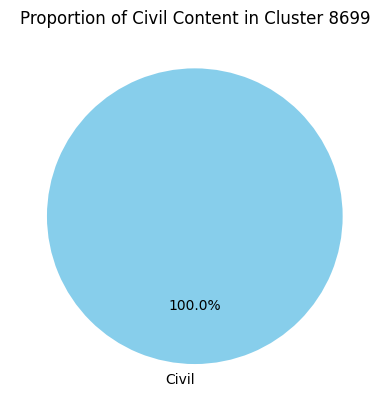

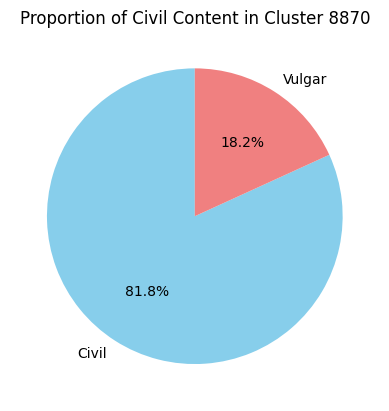

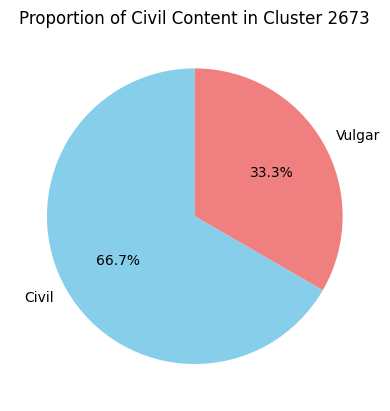

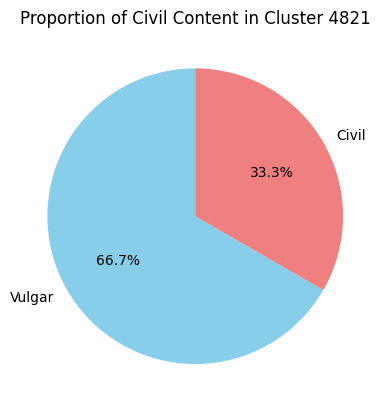

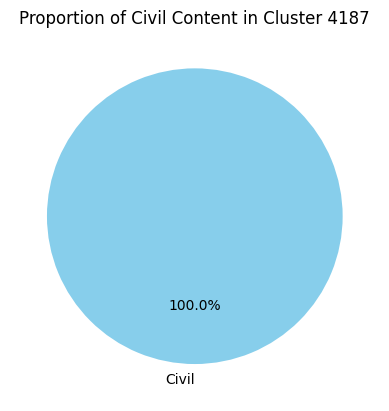

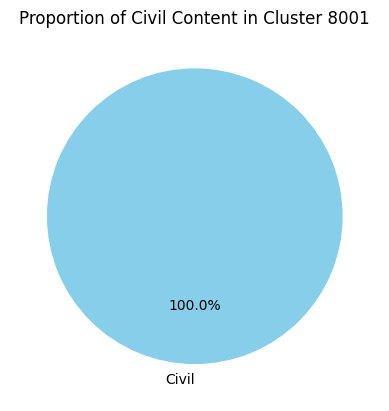

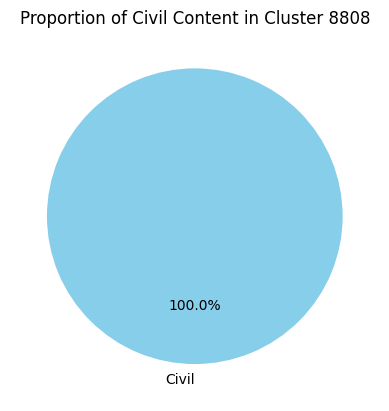

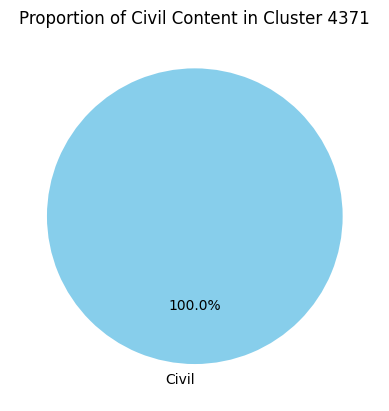

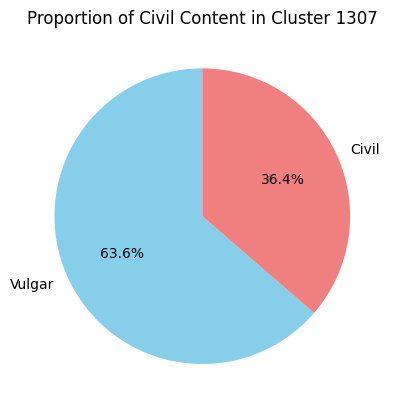

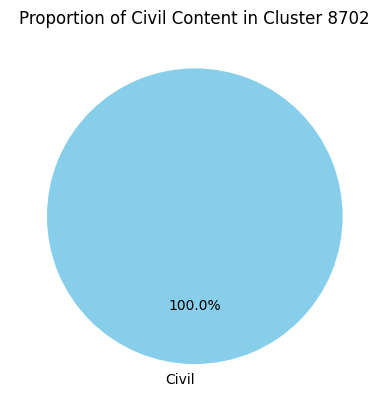

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert 'Timestamp' column to datetime
df_anies_cluster['Timestamp'] = pd.to_datetime(df_anies_cluster['Timestamp'], utc=True)

# Important dates
important_dates = [('2024-01-07', 'Debat ke-3'),
                   ('2024-01-11', 'Dialog Kadin'),
                   ('2024-01-17', 'Dialog KPK'),
                   ('2024-01-21', 'Debat ke-4')]

# Filter the DataFrame for the dates 3 days after Debat ke-3
debat_ke_3_date = pd.to_datetime('2024-01-07', utc=True)
start_date = debat_ke_3_date
end_date = debat_ke_3_date + pd.Timedelta(days=3)

df_filtered = df_anies_cluster[(df_anies_cluster['Timestamp'] >= start_date) &
                               (df_anies_cluster['Timestamp'] <= end_date)]

# Group by cluster and count the occurrences
cluster_counts = df_filtered['class'].value_counts().reset_index()
cluster_counts.columns = ['class', 'count']

# Check if the cluster existed before January 7, 2024
exist_before_date = df_anies_cluster[df_anies_cluster['Timestamp'] < start_date]['class'].unique()
cluster_counts['is_after'] = ~cluster_counts['class'].isin(exist_before_date)

# Sort by count
cluster_counts_sorted = cluster_counts.sort_values(by='count', ascending=False).reset_index(drop=True)

# Filter for clusters with is_after == True and take the top 10 clusters
top_clusters = cluster_counts_sorted[cluster_counts_sorted['is_after']].head(10)

# Filter the original dataframe for the top 10 clusters
df_top_clusters = df_anies_cluster[df_anies_cluster['class'].isin(top_clusters['class'])]

# Plot is_civil pie chart for each top-10 cluster where is_after == True
for cluster in top_clusters['class']:
    cluster_data = df_top_clusters[df_top_clusters['class'] == cluster]
    is_civil_counts = cluster_data['is_civil_pred'].value_counts()
    is_civil_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
    plt.title(f'Proportion of Civil Content in Cluster {cluster}')
    plt.ylabel('')
    plt.show()

In [ ]:
df_anies_cluster[df_anies_cluster['class'] == 2673]

                     Timestamp  num_retweets  \
2250 2024-01-09 20:49:03+00:00            11   
6544 2024-01-07 13:44:49+00:00            13   
7086 2024-01-07 17:14:57+00:00            16   

                                        content_cleaned anies_pred  \
2250  Omon omon ini trnyata yg bkin pak ngamuk mmg s...     Kontra   
6544  Kata pak omon omon data pak Anies salah ini bu...     Kontra   
7086  Yg disampaikan Anies baswedan adalah data yg d...     Kontra   

     prabowo_pred ganjar_pred is_civil_pred  \
2250       Kontra      Netral         Civil   
6544       Netral      Netral        Vulgar   
7086       Netral      Netral         Civil   

                                                  title     id  degree  class  \
2250  Tweet 5066: Omon omon ini trnyata yg bkin pak ...   5066       2   2673   
6544  Tweet 15649: Kata pak omon omon data pak Anies...  15649      11   2673   
7086  Tweet 17034: Yg disampaikan Anies baswedan ada...  17034      23   2673   

      class_